# PrevioPLS · Previsão de evasão pós-venda na rede Ford

**Challenge Ford · FIAP 2026 · Sprint 3 · Inteligência Artificial & Machine Learning**
Desafio 02: *Impulsionando o VIN Share na América do Sul com Soluções Inteligentes*

| Integrante | RM |
|---|---|
| Giovanne Charelli Zaniboni Silva | 556223 |
| Gustavo Oliveira de Moura | 555827 |
| Lynn Bueno Rosa | 551102 |

**Pergunta do notebook:** quando um veículo termina uma revisão na rede oficial, ele vai voltar para a próxima revisão no prazo? O modelo responde com uma probabilidade de evasão, e a concessionária usa essa probabilidade para decidir quem abordar antes de o cliente migrar para uma oficina independente.

**Base:** `vin_share_Desafio_02.xlsx`, a planilha oficial do desafio (602.788 linhas, 25 colunas). Todo o trabalho usa os dados reais da Ford, sem base sintética.

**Roteiro** (segue a ordem dos critérios da sprint)

1. Compreensão do problema
2. Preparação dos dados
3. Desenvolvimento dos modelos
4. Avaliação e comparação
5. Conclusão

In [1]:
import os, sys, gc, json, time, warnings
from pathlib import Path

os.environ.setdefault("PYTHONWARNINGS", "ignore")  # vale também pros workers do joblib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import sklearn
import xgboost
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, brier_score_loss,
                             classification_report, confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold,
                                     cross_val_predict)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.tree import DecisionTreeClassifier

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import features_revisao as fr
import inferencia

SEED = 42
# com 12 workers e árvore funda a busca estoura 16 GB de ram
N_JOBS = min(6, os.cpu_count() or 1)
DIR_FIG = RAIZ / "docs" / "figuras"
DIR_MODELO = RAIZ / "models"
DIR_FIG.mkdir(parents=True, exist_ok=True)
DIR_MODELO.mkdir(exist_ok=True)

AZUL, AZUL_MEDIO, AZUL_CLARO = "#003478", "#2F6DB5", "#9DB7DE"
VERMELHO, CINZA, CINZA_CLARO = "#C0392B", "#8A94A6", "#D5D9E0"
CORES = {
    "Baseline (Dummy)": "#B8BEC8", "Regressão Logística": "#6E8FC7", "KNN": "#8E7CC3",
    "Árvore de Decisão": "#C9A227", "Random Forest": "#3C9D6B", "XGBoost": AZUL, "MLP (rede neural)": "#D35400",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 10, "axes.edgecolor": "#C9CED6", "grid.color": "#E6E9EE",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def salvar(fig, nome):
    fig.savefig(DIR_FIG / f"{nome}.png", dpi=130, bbox_inches="tight")


print(f"python {sys.version.split()[0]} · pandas {pd.__version__} · scikit-learn {sklearn.__version__} · xgboost {xgboost.__version__}")

python 3.13.14 · pandas 3.0.6 · scikit-learn 1.9.1 · xgboost 3.4.1


---
# 1. Compreensão do problema

## 1.1 Contexto

O **VIN Share** mede quantos veículos Ford continuam fazendo manutenção na rede oficial. Quem sai da rede quase nunca volta: o cliente acha uma oficina independente mais barata ou mais perto, cria o hábito, e a Ford perde a receita de serviços, peças e o relacionamento que puxa a próxima venda.

Hoje a concessionária só percebe a saída quando a revisão já venceu e o cliente não apareceu. O **PrevioPLS**, a plataforma que o grupo vem construindo nas sprints anteriores, existe para inverter essa ordem: avisar o consultor **antes** do vencimento, com uma lista priorizada de quem tem mais risco de não voltar.

## 1.2 Objetivo da solução

Estimar, no fechamento de cada ordem de serviço de revisão, a **probabilidade de o veículo não voltar à rede oficial para a revisão seguinte dentro do prazo**. Com essa probabilidade:

- o consultor recebe no app os casos de maior risco, com antecedência de meses;
- o gestor acompanha o risco da carteira por loja e por modelo;
- a Ford direciona campanhas (desconto, lembrete, agendamento facilitado) para quem precisa, sem gastar margem com cliente fiel.

## 1.3 Dados disponíveis

A planilha `vin_share_Desafio_02.xlsx` traz uma aba `vin_share` com 25 colunas. Montamos o dicionário abaixo a partir do conteúdo das colunas. A coluna *quando é conhecida* é a que mais importa: uma variável só pode entrar no modelo se estiver disponível no momento da previsão (o fechamento da OS).

| Coluna | O que representa | Quando é conhecida | Uso |
|---|---|---|---|
| `Country` | país da rede | cadastro | descartada (constante: BRA) |
| `ScheduleID` | id do agendamento | visita | descartada (identificador) |
| `MaintenanceID` | id da manutenção, ou seja, **a visita** | visita | chave de agregação |
| `ServiceOrder` | nº da OS na loja | visita | descartada (identificador) |
| `ServiceDate` | data do serviço | visita | data da visita e construção do alvo |
| `ServiceOpenDate` / `ServiceClosedDate` | abertura e fechamento da OS | visita | duração da OS |
| `ServiceDeptCode` / `ServiceRepairTypeCode` | departamento e tipo de reparo | visita | descartadas (77% vazias) |
| `ServiceType` | tipo de serviço | visita | descartada (constante: Maintenance) |
| `ServiceCode` | código do serviço executado | visita | categórica |
| `MaintenanceNumber` | nº da revisão no plano (1ª, 2ª, ...) | visita | posição no plano |
| `DealerCode` | concessionária que fez o serviço | visita | loja e volume da loja |
| `MainSource` | origem do registro (agenda, manutenção oficial, GUDB) | visita | categórica |
| `IsAgendaSchedule` | visita agendada ou não | visita | binária |
| `StatusUSA` | status da OS | visita | descartada (constante: Concluded) |
| `VIN_Hash` | chassi pseudonimizado | cadastro | chave do veículo (não entra no modelo) |
| `ModelName` / `ModelYear` | modelo e ano-modelo | venda | veículo |
| `KM` | hodômetro na visita | visita | uso do veículo |
| `InvoiceDate` | faturamento Ford → concessionária (vem antes da venda) | antes da venda | tempo em estoque |
| `SalesDate` | venda ao cliente | venda | referência |
| `DeliveryDate` / `RegistrationDate` | entrega e emplacamento | ~venda | atrasos de entrega e emplacamento |
| `WarrantyStartDate` | início da garantia | ~venda | idade do veículo e fim da garantia |

Nenhuma coluna identifica pessoa: o chassi vem em hash e não há nome, CPF ou contato. A planilha é lida como texto (`dtype=str`) para que as conversões de tipo fiquem explícitas na preparação.

In [2]:
CAMINHO_XLSX = Path(os.environ.get("VIN_SHARE_XLSX", RAIZ / "data" / "vin_share_Desafio_02.xlsx"))
# opcional: pickle da planilha já lida, pra pular os ~3 min do openpyxl em reexecuções
CACHE = os.environ.get("VIN_SHARE_CACHE")

t0 = time.time()
if CACHE and Path(CACHE).exists():
    bruto = pd.read_pickle(CACHE)
else:
    bruto = pd.read_excel(CAMINHO_XLSX, sheet_name="vin_share", dtype=str)
print(f"{len(bruto):,} linhas × {bruto.shape[1]} colunas · lido em {time.time() - t0:.0f}s")

exibir = bruto.head(3).copy()
exibir["VIN_Hash"] = exibir["VIN_Hash"].str[:12] + "…"
exibir.T

602,788 linhas × 25 colunas · lido em 1s


,0,1,2
Country,BRA,BRA,BRA
ScheduleID,11829562,11874301,11894146
MaintenanceID,143124320,143131390,143139524
ServiceOrder,456022,7815,6882
ServiceDate,10/07/2023,10/14/2023,10/20/2023
ServiceOpenDate,10/07/2023,10/14/2023,10/20/2023
ServiceClosedDate,10/07/2023,10/14/2023,10/23/2023
ServiceDeptCode,NaN,NaN,NaN
ServiceRepairTypeCode,NaN,NaN,NaN
ServiceType,Maintenance,Maintenance,Maintenance


## 1.4 Primeira leitura

Antes de qualquer limpeza, precisamos entender a **granularidade**: o que é uma linha, o que é uma visita e o que é um veículo.

In [3]:
d_serv = pd.to_datetime(bruto["ServiceDate"], format="%m/%d/%Y", errors="coerce")
d_venda = pd.to_datetime(bruto["SalesDate"], format="%m/%d/%Y", errors="coerce")

visitas_brutas = bruto.drop_duplicates("MaintenanceID")
resumo = pd.Series({
    "linhas": f"{len(bruto):,}",
    "visitas distintas (MaintenanceID)": f"{bruto['MaintenanceID'].nunique():,}",
    "veículos distintos (VIN_Hash)": f"{bruto['VIN_Hash'].nunique():,}",
    "concessionárias": f"{bruto['DealerCode'].nunique():,}",
    "modelos": f"{bruto['ModelName'].nunique():,}",
    "período dos serviços": f"{d_serv.min():%d/%m/%Y} a {d_serv.max():%d/%m/%Y}",
    "período das vendas": f"{d_venda.min():%d/%m/%Y} a {d_venda.max():%d/%m/%Y}",
    "linhas por visita (média)": f"{len(bruto) / bruto['MaintenanceID'].nunique():.2f}",
    "visitas por veículo (média)": f"{len(visitas_brutas) / bruto['VIN_Hash'].nunique():.2f}",
}, name="valor")
resumo.to_frame()

,valor
linhas,"602,788"
visitas distintas (MaintenanceID),"537,177"
veículos distintos (VIN_Hash),"175,554"
concessionárias,435
modelos,20
período dos serviços,03/01/2020 a 04/05/2026
período das vendas,02/01/2020 a 10/04/2026
linhas por visita (média),1.12
visitas por veículo (média),3.06


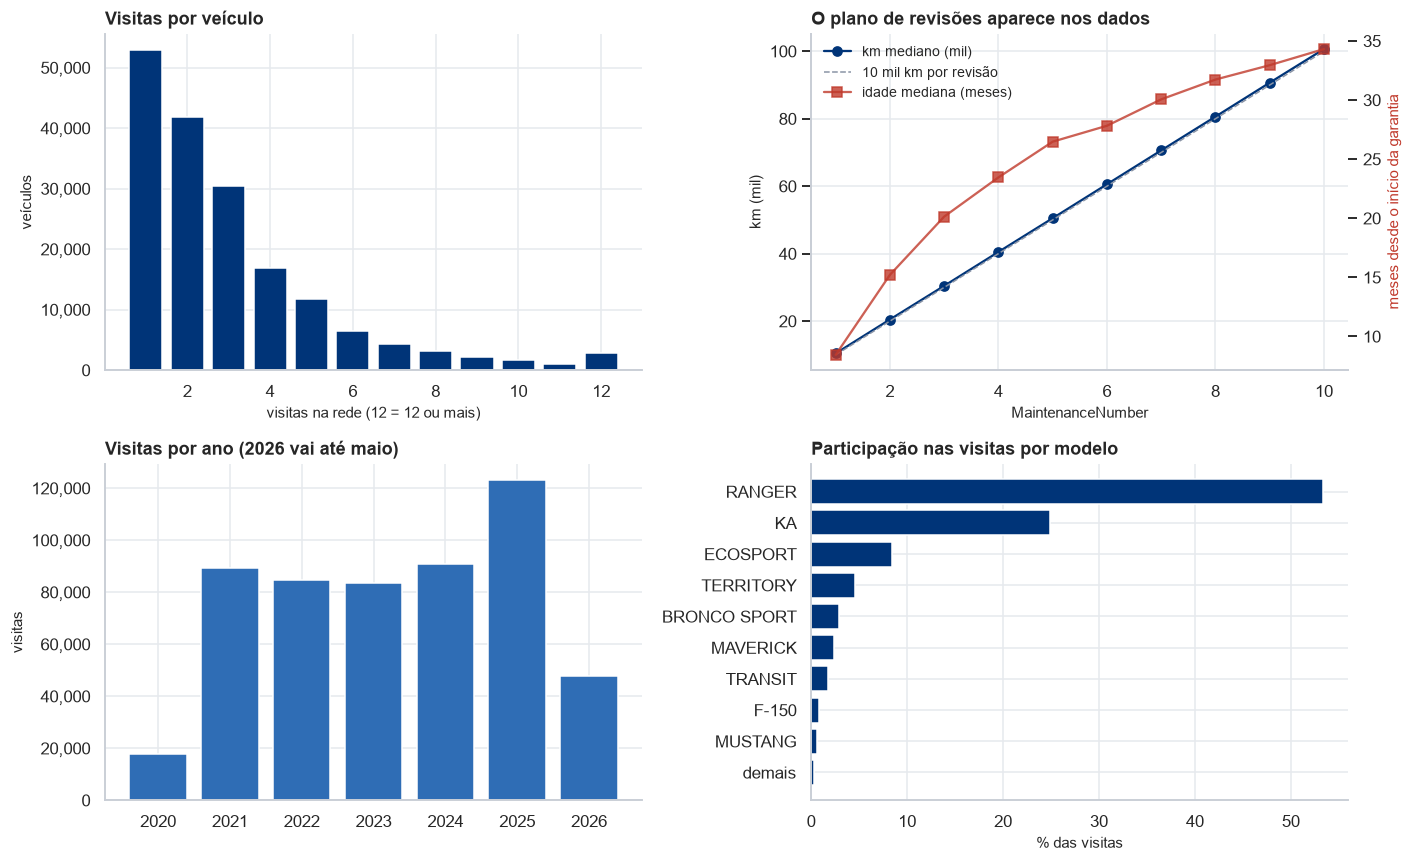

In [4]:
v0 = visitas_brutas.assign(
    rev=pd.to_numeric(visitas_brutas["MaintenanceNumber"], errors="coerce"),
    km=pd.to_numeric(visitas_brutas["KM"], errors="coerce"),
    data=pd.to_datetime(visitas_brutas["ServiceDate"], format="%m/%d/%Y"),
    garantia=pd.to_datetime(visitas_brutas["WarrantyStartDate"], format="%m/%d/%Y", errors="coerce"),
)
v0["idade"] = (v0["data"] - v0["garantia"]).dt.days

fig, ax = plt.subplots(2, 2, figsize=(13, 8))

por_vin = v0.groupby("VIN_Hash").size().clip(upper=12).value_counts().sort_index()
ax[0, 0].bar(por_vin.index, por_vin.values, color=AZUL)
ax[0, 0].set(title="Visitas por veículo", xlabel="visitas na rede (12 = 12 ou mais)", ylabel="veículos")
ax[0, 0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plano = v0[v0["rev"].between(1, 10) & v0["km"].between(100, 500_000)].groupby("rev").agg(km=("km", "median"), dias=("idade", "median"))
ax[0, 1].plot(plano.index, plano["km"] / 1000, "o-", color=AZUL, label="km mediano (mil)")
ax[0, 1].plot(plano.index, plano.index * 10, "--", color=CINZA, lw=1, label="10 mil km por revisão")
ax2 = ax[0, 1].twinx()
ax2.plot(plano.index, plano["dias"] / 30.44, "s-", color=VERMELHO, alpha=0.8, label="idade mediana (meses)")
ax2.set_ylabel("meses desde o início da garantia", color=VERMELHO)
ax2.grid(False)
ax[0, 1].set(title="O plano de revisões aparece nos dados", xlabel="MaintenanceNumber", ylabel="km (mil)")
h1, l1 = ax[0, 1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax[0, 1].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

ano = v0["data"].dt.year.value_counts().sort_index()
ax[1, 0].bar(ano.index.astype(str), ano.values, color=AZUL_MEDIO)
ax[1, 0].set(title="Visitas por ano (2026 vai até maio)", ylabel="visitas")
ax[1, 0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

mod = v0["ModelName"].value_counts()
mod = pd.concat([mod.head(9), pd.Series({"demais": mod.iloc[9:].sum()})])
ax[1, 1].barh(mod.index[::-1], mod.values[::-1] / mod.sum() * 100, color=AZUL)
ax[1, 1].set(title="Participação nas visitas por modelo", xlabel="% das visitas")
plt.tight_layout(); salvar(fig, "01_primeira_leitura"); plt.show()

**O que a primeira leitura mostra**

- Cada linha é um **item** de serviço; uma visita (`MaintenanceID`) tem em média 1,12 linha, e parte disso são linhas duplicadas. A unidade de análise precisa ser a visita, não a linha.
- A base só tem **manutenções concluídas** (`ServiceType` e `StatusUSA` são constantes). Todo veículo presente passou pelo menos uma vez na rede.
- O **plano de revisões está nos dados**: o km mediano da revisão *n* fica em torno de *n* × 10 mil km. A idade mediana na 1ª revisão é de uns 8 meses, ou seja, a maioria dos carros bate os 10 mil km antes dos 12 meses. Por isso o vencimento precisa considerar o uso de cada veículo, e não só o calendário.
- Ranger e Ka somam quase 80% das visitas. Ka e EcoSport saíram de linha em 2021, então essa frota envelhece dentro da base.

## 1.5 Caracterização do problema

**Classificação binária supervisionada.** Para cada revisão feita na rede, o alvo é:

- `evasao = 1`: o veículo **não voltou** à rede até o vencimento da próxima revisão + 90 dias de tolerância;
- `evasao = 0`: voltou dentro desse prazo.

O vencimento segue o plano que o próprio dado mostra no gráfico acima: **10 mil km ou 12 meses, o que vier primeiro**. Como o hodômetro só é lido na visita, estimamos quando o carro chega aos próximos 10 mil km pela quilometragem média diária até ali.

Por que este recorte, e não outro:

| Alternativa | Por que não foi o recorte principal |
|---|---|
| Classificar o comprador no dia da venda (D0), como no pitch original do PrevioPLS | A planilha só contém veículos que **já fizeram pelo menos uma manutenção na rede**. Quem comprou e nunca apareceu não está na base, então não existe o grupo de comparação para aprender "quem nunca vem". A seção 3.11 mede quanto as variáveis de venda explicam sozinhas. |
| Multiclasse com os 4 perfis do PrevioPLS (Fiel, Econômico, Esquecido, Abandono) | "Econômico" depende de preço, e a base não tem valor de serviço. Os perfis viram uma regra de negócio em cima do score (seção 5). |
| Regressão do tempo até a próxima visita | Muitos veículos ainda não voltaram na data da extração (censura à direita). Tratar isso direito pede análise de sobrevivência, que fica como trabalho futuro. |

A classificação binária no fechamento da OS usa só informação disponível naquele momento, tem rótulo observável para a maioria das visitas e gera exatamente o que o consultor precisa: uma fila ordenada por risco.

---
# 2. Preparação dos dados

## 2.1 Diagnóstico de qualidade

Primeiro medimos os problemas; as decisões vêm na seção seguinte.

In [5]:
COLS_DATA = ["ServiceDate", "ServiceOpenDate", "ServiceClosedDate", "InvoiceDate", "SalesDate",
             "DeliveryDate", "RegistrationDate", "WarrantyStartDate"]

diag = pd.DataFrame({
    "faltantes_%": bruto.isna().mean().mul(100).round(2),
    "distintos": bruto.nunique(),
    "exemplo": bruto.apply(lambda s: str(s.dropna().iloc[0])[:18] if s.notna().any() else None),
})
diag["situação"] = np.select([diag["distintos"] <= 1, diag["faltantes_%"] > 50],
                             ["constante", "muito esparsa"], "")
diag

,faltantes_%,distintos,exemplo,situação
Country,0.0000,1,BRA,constante
ScheduleID,18.0900,430666,11829562,
MaintenanceID,0.0000,537177,143124320,
ServiceOrder,0.1200,286051,456022,
ServiceDate,0.0000,1959,10/07/2023,
ServiceOpenDate,0.0000,1958,10/07/2023,
ServiceClosedDate,0.0000,2094,10/07/2023,
ServiceDeptCode,77.0400,5,S,muito esparsa
ServiceRepairTypeCode,76.9600,6,C,muito esparsa
ServiceType,0.0000,1,Maintenance,constante


In [6]:
d = {c: pd.to_datetime(bruto[c], format="%m/%d/%Y", errors="coerce") for c in COLS_DATA}
km_b = pd.to_numeric(bruto["KM"], errors="coerce")
rev_b = pd.to_numeric(bruto["MaintenanceNumber"], errors="coerce")
linhas_por_visita = bruto.groupby("MaintenanceID").size()
extracao = d["ServiceDate"].max()
estoque = (d["SalesDate"] - d["InvoiceDate"]).dt.days

checagens = pd.Series({
    "linhas duplicadas (idênticas)": bruto.duplicated().sum(),
    "visitas com mais de uma linha": (linhas_por_visita > 1).sum(),
    "datas fora do formato mm/dd/aaaa": sum(int((d[c].isna() & bruto[c].notna()).sum()) for c in COLS_DATA),
    "MaintenanceNumber ≥ 50 (fora do plano)": (rev_b >= 50).sum(),
    "KM ausente": km_b.isna().sum(),
    "KM < 100": (km_b < 100).sum(),
    "KM > 500 mil": (km_b > 500_000).sum(),
    "OS fechada antes de abrir": (d["ServiceClosedDate"] < d["ServiceOpenDate"]).sum(),
    "OS fechada depois da extração": (d["ServiceClosedDate"] > extracao).sum(),
    "entrega antes da venda": (d["DeliveryDate"] < d["SalesDate"]).sum(),
    "entrega mais de 1 ano após a venda": ((d["DeliveryDate"] - d["SalesDate"]).dt.days > 365).sum(),
    "faturamento (InvoiceDate) depois da venda": (estoque < 0).sum(),
    "serviço antes do início da garantia": (d["ServiceDate"] < d["WarrantyStartDate"]).sum(),
    "modelos com menos de 1.000 linhas": (bruto["ModelName"].value_counts() < 1000).sum(),
}, name="linhas").to_frame()
checagens["% da base"] = (checagens["linhas"] / len(bruto) * 100).round(3)
print(f"InvoiceDate antes ou no dia da venda em {(estoque >= 0).mean():.1%} das linhas · "
      f"mediana de {estoque[estoque >= 0].median():.0f} dias em estoque")
checagens

InvoiceDate antes ou no dia da venda em 99.4% das linhas · mediana de 31 dias em estoque


,linhas,% da base
linhas duplicadas (idênticas),62948,10.4430
visitas com mais de uma linha,26854,4.4550
datas fora do formato mm/dd/aaaa,0,0.0000
MaintenanceNumber ≥ 50 (fora do plano),1613,0.2680
KM ausente,2541,0.4220
KM < 100,933,0.1550
KM > 500 mil,105,0.0170
OS fechada antes de abrir,207,0.0340
OS fechada depois da extração,1,0.0000
entrega antes da venda,11056,1.8340


**Leitura do diagnóstico**

- **10,4% das linhas são duplicatas exatas**, o maior problema em volume. Sem remover, a mesma visita contaria duas vezes.
- Os campos de data estão todos no mesmo formato `mm/dd/aaaa` (com ou sem zero à esquerda) e nenhum falhou na conversão. O risco estava no parser automático, que leria `10/07/2023` como 10 de julho.
- `InvoiceDate` cai antes ou no dia da venda em 99,4% das linhas, com mediana de 31 dias. Isso confirma a leitura de **faturamento para a concessionária**, e a diferença até a venda vira o tempo em estoque.
- Os demais problemas (KM impossível, entrega antes da venda, OS fechada antes de abrir) somam menos de 2% das linhas cada. Eles viram faltante, e o imputador trata; remover a visita inteira jogaria fora o resto da informação dela.

## 2.2 Limpeza

Cada decisão fica registrada numa tabela de log, com quantas linhas ou valores ela afetou.

| Problema | Decisão | Justificativa |
|---|---|---|
| Linhas idênticas | remover | reprocessamento da carga; duplicaria visitas |
| Colunas constantes (`Country`, `ServiceType`, `StatusUSA`) | descartar | variância zero, não discriminam nada |
| `ServiceDeptCode` e `ServiceRepairTypeCode` | descartar | 77% vazias; imputar criaria informação que não existe |
| Identificadores (`ScheduleID`, `ServiceOrder`) | descartar | sem significado preditivo |
| Datas em texto | converter com formato fixo `mm/dd/aaaa` | evita a inversão dia/mês que o parser automático faria |
| `MaintenanceNumber` 52 e 99 | remover | códigos especiais, não são revisões do plano |
| Várias linhas por `MaintenanceID` | agregar por visita | cada linha é um item do serviço, a unidade de análise é a visita |
| Mesmo VIN com duas visitas no mesmo dia | manter uma | é a mesma passagem registrada duas vezes |
| KM fora de 100 a 500 mil, acima de 1.000 km/dia de média, ou menor que numa visita anterior | anular (vira faltante) | leitura de hodômetro impossível; o imputador do pipeline trata |
| Modelos com menos de 1.000 visitas | agrupar em `OUTROS` | categorias raras não têm exemplos para o modelo aprender |
| Datas de entrega, emplacamento, faturamento e OS fora de faixa plausível | anular no cálculo da feature | tratado dentro de `features_revisao.py`, igual no treino e em produção |

In [7]:
log = []


def registrar(etapa, afetadas, depois, decisao):
    log.append({"etapa": etapa, "afetadas": int(afetadas), "tamanho depois": int(depois), "decisão": decisao})


limpo = bruto.drop_duplicates()
registrar("linhas idênticas", len(bruto) - len(limpo), len(limpo), "remover")

limpo = limpo.drop(columns=["Country", "ServiceType", "StatusUSA", "ServiceDeptCode",
                            "ServiceRepairTypeCode", "ScheduleID", "ServiceOrder"])
for c in COLS_DATA:
    limpo[c] = pd.to_datetime(limpo[c], format="%m/%d/%Y", errors="coerce")
for c in ["MaintenanceNumber", "KM", "ModelYear"]:
    limpo[c] = pd.to_numeric(limpo[c], errors="coerce")

antes = len(limpo)
limpo = limpo[limpo["MaintenanceNumber"] < 50]
registrar("revisão fora do plano (52, 99)", antes - len(limpo), len(limpo), "remover")

vis = (limpo.groupby("MaintenanceID", sort=False)
       .agg(vin=("VIN_Hash", "first"), data=("ServiceDate", "min"), abertura=("ServiceOpenDate", "min"),
            fechamento=("ServiceClosedDate", "max"), revisao=("MaintenanceNumber", "min"), km=("KM", "max"),
            concessionaria=("DealerCode", "first"), fonte=("MainSource", "first"),
            agendado=("IsAgendaSchedule", "first"), codigo_servico=("ServiceCode", "first"),
            itens=("ServiceCode", "size"), modelo=("ModelName", "first"), ano_modelo=("ModelYear", "first"),
            data_nf=("InvoiceDate", "first"), data_venda=("SalesDate", "first"),
            data_entrega=("DeliveryDate", "first"), data_emplacamento=("RegistrationDate", "first"),
            data_garantia=("WarrantyStartDate", "first"))
       .reset_index().rename(columns={"MaintenanceID": "id_visita"}))
registrar("linhas → visitas (MaintenanceID)", len(limpo) - len(vis), len(vis), "agregar")
vis["agendado"] = vis["agendado"].eq("True")

antes = len(vis)
vis = vis.sort_values(["vin", "data", "revisao"]).drop_duplicates(["vin", "data"], keep="last")
registrar("mesmo VIN, mesmo dia", antes - len(vis), len(vis), "manter a de maior revisão")
vis = vis.sort_values(["vin", "data"], kind="stable").reset_index(drop=True)

km_fora = vis["km"].notna() & ~vis["km"].between(100, 500_000)
vis.loc[km_fora, "km"] = np.nan
registrar("KM fora de [100, 500 mil]", km_fora.sum(), len(vis), "anular")
idade_visita = (vis["data"] - vis["data_garantia"]).dt.days.clip(lower=30)
km_impossivel = vis["km"] / idade_visita > 1000
vis.loc[km_impossivel, "km"] = np.nan
registrar("KM incompatível com a idade (> 1.000 km/dia)", km_impossivel.sum(), len(vis), "anular")
km_max_ant = vis.groupby("vin")["km"].cummax().groupby(vis["vin"]).shift(1)
km_voltou = vis["km"] < km_max_ant
vis.loc[km_voltou, "km"] = np.nan
registrar("KM menor que em visita anterior", km_voltou.sum(), len(vis), "anular")

vis["modelo"] = vis["modelo"].fillna("OUTROS")
contagem = vis["modelo"].value_counts()
raros = contagem[contagem < 1000].index
registrar(f"modelos raros ({len(raros)} nomes)", vis["modelo"].isin(raros).sum(), len(vis), "agrupar em OUTROS")
vis["modelo"] = vis["modelo"].where(~vis["modelo"].isin(raros), "OUTROS")

pd.DataFrame(log)

,etapa,afetadas,tamanho depois,decisão
0,linhas idênticas,62948,539840,remover
1,"revisão fora do plano (52, 99)",1466,538374,remover
2,linhas → visitas (MaintenanceID),2657,535717,agregar
3,"mesmo VIN, mesmo dia",1293,534424,manter a de maior revisão
4,"KM fora de [100, 500 mil]",899,534424,anular
5,KM incompatível com a idade (> 1.000 km/dia),154,534424,anular
6,KM menor que em visita anterior,2203,534424,anular
7,modelos raros (12 nomes),1111,534424,agrupar em OUTROS


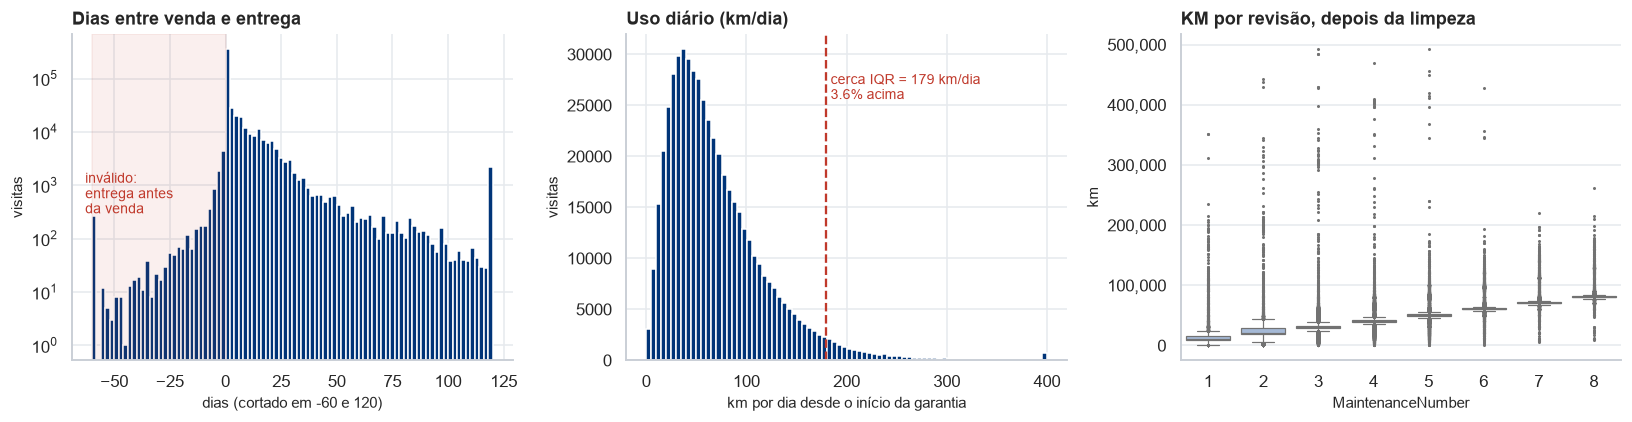

In [8]:
lag_entrega_bruto = (vis["data_entrega"] - vis["data_venda"]).dt.days
km_dia_bruto = vis["km"] / (vis["data"] - vis["data_garantia"]).dt.days.clip(lower=30)
q1, q3 = km_dia_bruto.quantile([0.25, 0.75])
cerca = q3 + 1.5 * (q3 - q1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(lag_entrega_bruto.clip(-60, 120), bins=90, color=AZUL)
ax[0].axvspan(-60, 0, color=VERMELHO, alpha=0.08)
ax[0].set(title="Dias entre venda e entrega", xlabel="dias (cortado em -60 e 120)", ylabel="visitas", yscale="log")
ax[0].text(0.03, 0.45, "inválido:\nentrega antes\nda venda", color=VERMELHO, fontsize=9, transform=ax[0].transAxes)

ax[1].hist(km_dia_bruto.clip(upper=400), bins=80, color=AZUL)
ax[1].axvline(cerca, color=VERMELHO, ls="--")
ax[1].set(title="Uso diário (km/dia)", xlabel="km por dia desde o início da garantia", ylabel="visitas")
ax[1].text(cerca + 5, ax[1].get_ylim()[1] * 0.8, f"cerca IQR = {cerca:.0f} km/dia\n{(km_dia_bruto > cerca).mean():.1%} acima", color=VERMELHO, fontsize=9)

amostra_box = vis[vis["revisao"].between(1, 8)]
sns.boxplot(data=amostra_box, x="revisao", y="km", ax=ax[2], color=AZUL_CLARO, fliersize=1, linewidth=0.8)
ax[2].set(title="KM por revisão, depois da limpeza", xlabel="MaintenanceNumber", ylabel="km")
ax[2].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); salvar(fig, "02_outliers"); plt.show()

**Outliers: erro ou comportamento real?**

- **Entrega antes da venda** é impossível: é erro de digitação e vira faltante. Esperas longas, mas positivas, são reais (carro encomendado) e ficam.
- No **uso diário**, a regra do IQR marca como outlier os carros que rodam muito. Eles não são erro, são frota e uso profissional, justamente um perfil com comportamento diferente de retorno. Por isso **não removemos outliers estatísticos**: eles ficam e passam por `log1p` quando isso reduz a assimetria. Só saem os valores fisicamente impossíveis: KM abaixo de 100 ou acima de 500 mil, média acima de 1.000 km/dia (o boxplot antes da regra mostrava carro com 430 mil km na 1ª revisão) e hodômetro que volta.
- Depois da limpeza, o KM por revisão fica bem comportado em degraus de 10 mil km, o que confirma que as regras não distorceram a base.

## 2.3 Construção do alvo

Para cada visita:

1. estimamos o uso diário (`km_dia`) com a leitura atual do hodômetro; se ela faltar, usamos a última leitura válida do veículo e, na falta das duas, a mediana do modelo;
2. calculamos quantos dias faltam para a próxima revisão: `min(365, 10.000 / km_dia)`;
3. somamos 90 dias de tolerância e obtemos o **limite**;
4. `evasao = 1` se não houver nenhuma visita do mesmo VIN até o limite.

**Censura:** se o limite cai depois da data de extração, ainda não sabemos o desfecho. Essas visitas ficam fora do treino e do teste, e são justamente as que o modelo pontua em produção (seção 5.4).

In [9]:
# a planilha bruta não é mais usada daqui pra frente: libera memória pros workers da busca
del bruto, limpo, d, v0, visitas_brutas, km_b, rev_b, d_serv, d_venda, estoque, linhas_por_visita
gc.collect()

X_todas = fr.montar_features(vis)
DATA_EXTRACAO = vis["data"].max()


def construir_alvo(vis, km_dia, tolerancia):
    prox = vis.groupby("vin")["data"].shift(-1)
    kd = km_dia.groupby(vis["vin"]).ffill()
    kd = kd.fillna(kd.groupby(vis["modelo"]).transform("median"))
    dias_ate = np.minimum(fr.DIAS_PLANO, fr.KM_PLANO / kd.clip(lower=1))
    limite = vis["data"] + pd.to_timedelta(dias_ate + tolerancia, unit="D")
    evasao = (prox.isna() | (prox > limite)).astype(int)
    return evasao, limite, prox


TOLERANCIA = 90
y_todas, limite, prox_visita = construir_alvo(vis, X_todas["km_dia"], TOLERANCIA)
observavel = limite <= DATA_EXTRACAO
print(f"extração: {DATA_EXTRACAO:%d/%m/%Y} · visitas com desfecho observável: {observavel.sum():,} de {len(vis):,} ({observavel.mean():.1%})")
print(f"taxa de evasão nas observáveis: {y_todas[observavel].mean():.1%}")

sens = []
for tol in [30, 90, 180]:
    y_t, lim_t, _ = construir_alvo(vis, X_todas["km_dia"], tol)
    obs_t = lim_t <= DATA_EXTRACAO
    tardio = (prox_visita.notna() & (prox_visita > lim_t))[obs_t]
    sens.append({"tolerância (dias)": tol, "visitas observáveis": int(obs_t.sum()),
                 "evasão": y_t[obs_t].mean(), "voltou, mas atrasado": tardio.mean(),
                 "não voltou até a extração": y_t[obs_t].mean() - tardio.mean()})
pd.DataFrame(sens).set_index("tolerância (dias)")

extração: 04/05/2026 · visitas com desfecho observável: 438,168 de 534,424 (82.0%)
taxa de evasão nas observáveis: 34.4%


,visitas observáveis,evasão,"voltou, mas atrasado",não voltou até a extração
tolerância (dias),,,,
30,459215,0.5235,0.2938,0.2297
90,438168,0.3441,0.1298,0.2143
180,407813,0.2572,0.0497,0.2075


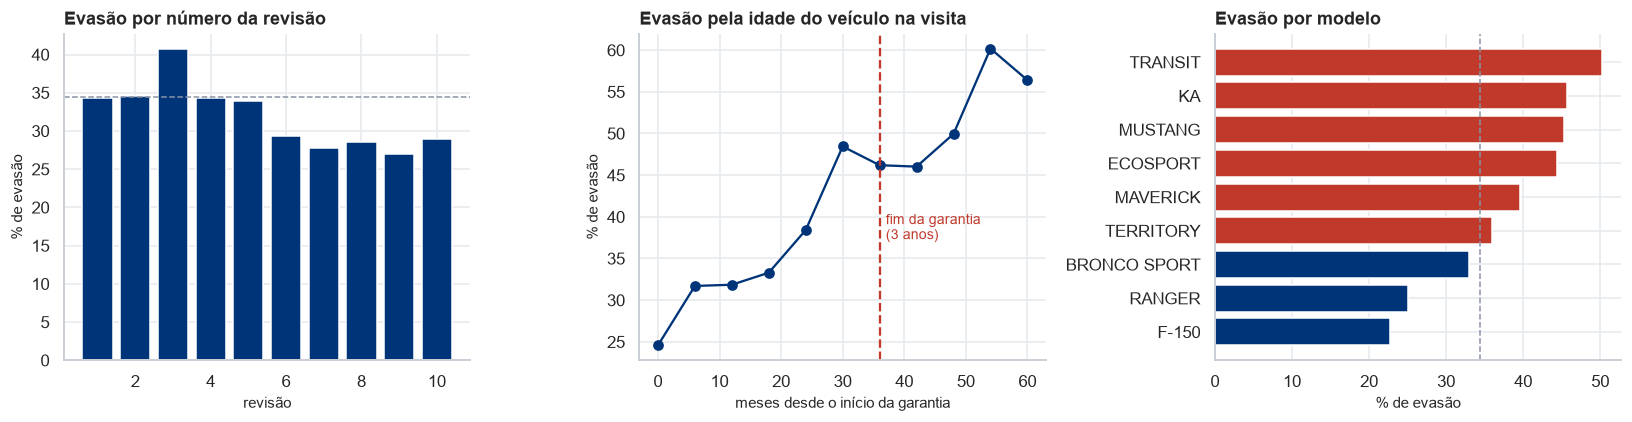

In [10]:
obs = vis[observavel].assign(evasao=y_todas[observavel], idade_m=X_todas.loc[observavel, "idade_dias"] / 30.44)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

r = obs[obs["revisao"] <= 10].groupby("revisao")["evasao"].mean()
ax[0].bar(r.index, r.values * 100, color=AZUL)
ax[0].axhline(obs["evasao"].mean() * 100, color=CINZA, ls="--", lw=1)
ax[0].set(title="Evasão por número da revisão", xlabel="revisão", ylabel="% de evasão")

faixa = (obs["idade_m"] // 6 * 6).clip(upper=60)
r = obs.groupby(faixa)["evasao"].mean()
ax[1].plot(r.index, r.values * 100, "o-", color=AZUL)
ax[1].axvline(36, color=VERMELHO, ls="--")
ax[1].text(37, r.max() * 100 * 0.62, "fim da garantia\n(3 anos)", color=VERMELHO, fontsize=9)
ax[1].set(title="Evasão pela idade do veículo na visita", xlabel="meses desde o início da garantia", ylabel="% de evasão")

r = obs.groupby("modelo")["evasao"].agg(["mean", "size"]).query("size > 1000").sort_values("mean")
ax[2].barh(r.index, r["mean"] * 100, color=[VERMELHO if m > obs["evasao"].mean() else AZUL for m in r["mean"]])
ax[2].axvline(obs["evasao"].mean() * 100, color=CINZA, ls="--", lw=1)
ax[2].set(title="Evasão por modelo", xlabel="% de evasão")
plt.tight_layout(); salvar(fig, "03_alvo"); plt.show()

**O alvo**

- Com 90 dias de tolerância, **34,4% das revisões não são seguidas de outra no prazo**. Desses, 13 pontos são clientes que voltaram atrasados e 21 pontos não voltaram até a extração.
- A tolerância muda muito a taxa (52% com 30 dias, 26% com 180). Ficamos com 90 dias porque é o meio-termo operacional: com 30, contaria como evasão quem só agendou algumas semanas depois; com 180, o cliente já teria pulado uma revisão inteira antes de o modelo acusar. A parte "não voltou até a extração" quase não muda (21% a 23%), então o núcleo do problema é estável.
- **A evasão sobe perto do fim da garantia.** Até 6 meses de uso ela fica em torno de 25%; a partir de 30 meses, quando a próxima revisão já cai depois dos 3 anos, passa de 45%. Esse efeito vira a feature `proxima_fora_garantia`.
- Ka, EcoSport e Transit evadem bem acima da média; Ranger e F-150, abaixo. Modelos descontinuados envelhecem para fora da garantia, e vans de frota tendem a ter oficina própria.
- 18% das visitas ainda não têm desfecho (janela aberta na extração). Elas não entram no treino nem no teste.

## 2.4 Criação de variáveis

As features ficam em `src/features_revisao.py`, uma função única que o notebook usa para treinar e o `src/inferencia.py` usa para classificar. Assim a conta feita em produção é exatamente a mesma do treino.

| Grupo | Feature | O que mede |
|---|---|---|
| veículo | `modelo`, `defasagem_ano_modelo` | modelo; ano-modelo menos ano da venda (estoque do ano anterior) |
| veículo | `dias_estoque` | dias entre o faturamento para a loja e a venda |
| veículo | `lag_entrega`, `lag_emplacamento`, `mes_venda` | atraso na entrega e no emplacamento; sazonalidade da venda |
| visita | `revisao`, `km`, `idade_dias`, `km_dia` | posição no plano, hodômetro, idade do veículo, intensidade de uso |
| visita | `agendado`, `fonte`, `codigo_servico` | se agendou, origem do registro, código do serviço |
| visita | `duracao_os`, `mes_visita` | dias com o carro na oficina; sazonalidade |
| plano | `atraso_plano_dias`, `km_excedente` | quanto a revisão atual atrasou em tempo e em km |
| plano | `dias_ate_proxima`, `proxima_fora_garantia`, `dias_restantes_garantia` | quando vence a próxima e se ela cai depois da garantia |
| histórico | `n_visitas_anteriores`, `intervalo_dias`, `km_desde_anterior` | relacionamento acumulado e ritmo desde a última visita |
| histórico | `revisoes_puladas` | revisões do plano que não passaram pela rede |
| histórico | `trocou_concessionaria`, `n_concessionarias`, `atraso_medio_hist` | fidelidade à loja e pontualidade média |
| loja | `concessionaria`, `volume_loja_12m` | a loja e quantas visitas ela atendeu nos 12 meses anteriores |

O histórico usa `shift` e soma acumulada dentro de cada VIN, então cada linha só enxerga as visitas anteriores a ela.

In [11]:
t0 = time.time()
X_todas = fr.montar_features(vis)
print(f"{X_todas.shape[1]} features candidatas para {len(X_todas):,} visitas em {time.time() - t0:.1f}s")
X_todas.describe().T[["mean", "50%", "min", "max"]].join(X_todas.isna().mean().rename("faltantes"))

29 features candidatas para 534,424 visitas em 2.4s


,mean,50%,min,max,faltantes
defasagem_ano_modelo,0.3699,0.0000,-2.0000,2.0000,0.0000
dias_estoque,55.1227,33.0000,0.0000,727.0000,0.0026
lag_entrega,4.7282,0.0000,0.0000,365.0000,0.0184
lag_emplacamento,1.6408,0.0000,-30.0000,365.0000,0.0105
mes_venda,6.3809,6.0000,1.0000,12.0000,0.0000
revisao,3.2226,2.0000,1.0000,48.0000,0.0000
km,"34,619.8010","25,822.0000",100.0000,"493,470.0000",0.0114
idade_dias,573.4815,458.0000,0.0000,"2,310.0000",0.0006
km_dia,70.7577,58.5394,0.1427,997.9911,0.0114
agendado,0.9389,1.0000,0.0000,1.0000,0.0000


## 2.5 Verificação anti-vazamento

Vazamento aqui seria usar algo que só se sabe **depois** da visita: a data da próxima passagem, o total de visitas do VIN, a última data vista. Duas verificações rodam sempre que o notebook executa:

1. **Por construção:** nenhuma coluna do alvo aparece entre as features.
2. **Por truncamento:** cortamos a base numa data *t*, recalculamos as features só com o passado e comparamos com as features das visitas do dia *t* calculadas na base inteira. Se alguma feature olhasse para o futuro, os dois valores seriam diferentes. O teste interrompe o notebook se isso acontecer.

In [12]:
PROIBIDAS = {"prox_visita", "limite", "evasao", "total_visitas", "ultima_visita", "data"}
assert not PROIBIDAS & set(X_todas.columns), "coluna do futuro entre as features"

datas_teste = vis["data"].drop_duplicates().sample(6, random_state=SEED).sort_values()
inicio = vis["data"].min()
for dt in datas_teste:
    passado = vis[vis["data"] <= dt]
    f_passado = fr.montar_features(passado, inicio_base=inicio)
    idx = passado.index[passado["data"] == dt]
    pd.testing.assert_frame_equal(f_passado.loc[idx], X_todas.loc[idx], check_dtype=False)
    print(f"{dt:%d/%m/%Y}: {len(idx):>4} visitas com features idênticas usando só o passado")
print("ok: nenhuma feature depende de informação posterior à visita")

06/06/2020:   13 visitas com features idênticas usando só o passado


05/04/2023:  304 visitas com features idênticas usando só o passado


03/06/2023:   78 visitas com features idênticas usando só o passado


08/07/2024:  314 visitas com features idênticas usando só o passado


16/09/2024:  303 visitas com features idênticas usando só o passado


19/06/2025:   46 visitas com features idênticas usando só o passado
ok: nenhuma feature depende de informação posterior à visita


## 2.6 Divisão em treino e teste

A divisão é **temporal**, porque em produção o modelo sempre vai prever visitas futuras com o que aprendeu do passado:

- **treino**: visitas cujo desfecho já era conhecido em **01/07/2024** (o limite da janela vence antes do corte). É o que a Ford teria em mãos se treinasse o modelo naquele dia;
- **teste**: visitas feitas **a partir de 01/07/2024**, com desfecho observável até a extração;
- **sem rótulo**: janela ainda aberta, usadas só para pontuar no fim.

Dentro do treino, a validação cruzada agrupa por **VIN** (`StratifiedGroupKFold`), para que visitas do mesmo carro não caiam ao mesmo tempo em treino e validação e inflem as métricas.

In [13]:
CORTE = pd.Timestamp("2024-07-01")
y = y_todas
idx_treino = vis.index[observavel & (limite <= CORTE)]
idx_teste = vis.index[observavel & (vis["data"] >= CORTE)]
idx_aberto = vis.index[~observavel]

divisao = pd.DataFrame({
    "visitas": [len(idx_treino), len(idx_teste), len(idx_aberto)],
    "veículos": [vis.loc[i, "vin"].nunique() for i in (idx_treino, idx_teste, idx_aberto)],
    "período": [f"{vis.loc[i, 'data'].min():%m/%Y} a {vis.loc[i, 'data'].max():%m/%Y}" for i in (idx_treino, idx_teste, idx_aberto)],
    "evasão": [y[idx_treino].mean(), y[idx_teste].mean(), np.nan],
}, index=["treino", "teste", "sem rótulo (produção)"])
print(f"VINs em treino e teste ao mesmo tempo: {len(set(vis.loc[idx_treino, 'vin']) & set(vis.loc[idx_teste, 'vin'])):,} "
      "(visitas diferentes do mesmo carro, em épocas diferentes: é o uso real)")
divisao

VINs em treino e teste ao mesmo tempo: 23,591 (visitas diferentes do mesmo carro, em épocas diferentes: é o uso real)


,visitas,veículos,período,evasão
treino,250383,97002,01/2020 a 03/2024,0.3340
teste,122212,67775,07/2024 a 01/2026,0.3562
sem rótulo (produção),96256,81484,02/2025 a 05/2026,NaN


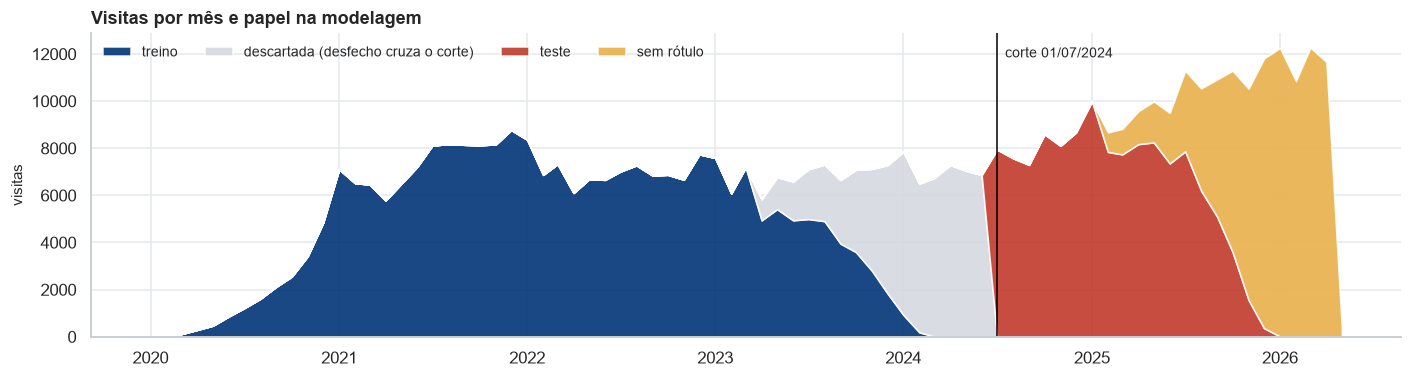

In [14]:
mes = vis["data"].dt.to_period("M").dt.to_timestamp()
grupo = pd.Series("sem rótulo", index=vis.index)
grupo[idx_treino] = "treino"
grupo[idx_teste] = "teste"
grupo[observavel & (limite > CORTE) & (vis["data"] < CORTE)] = "descartada (desfecho cruza o corte)"
tab = pd.crosstab(mes, grupo)[["treino", "descartada (desfecho cruza o corte)", "teste", "sem rótulo"]]

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.stackplot(tab.index, tab.T.values, labels=tab.columns, colors=[AZUL, CINZA_CLARO, VERMELHO, "#E8B04B"], alpha=0.9)
ax.axvline(CORTE, color="black", lw=1)
ax.text(CORTE, ax.get_ylim()[1] * 0.92, "  corte 01/07/2024", fontsize=9)
ax.set(title="Visitas por mês e papel na modelagem", ylabel="visitas")
ax.legend(loc="upper left", fontsize=9, ncol=4)
plt.tight_layout(); salvar(fig, "04_divisao_temporal"); plt.show()

## 2.7 Seleção de variáveis

A seleção usa **somente o treino**; olhar o teste aqui já seria vazamento. Dois critérios:

1. **Informação mútua** com o alvo, comparada com referências de puro ruído. A estimativa nunca dá zero exato, vem inflada em variáveis com muitos níveis e, nas contínuas, o estimador por vizinhos oscila na terceira casa decimal de uma semente para outra. Por isso cada valor é a **média de 5 repetições** em subamostras de 50 mil visitas, e as referências são:
   - contínuas precisam superar o **maior de 5 ruídos contínuos**;
   - loja e código de serviço (centenas de níveis) precisam superar 1,5× um ruído com os mesmos 435 níveis da concessionária;
   - as demais discretas precisam passar de 1e-4. Com *k* níveis e *N* linhas, o viés esperado é da ordem de (k−1)/2N, cerca de 3e-5 para 4 níveis e 50 mil linhas.
2. **Redundância:** entre pares com correlação de Spearman acima de 0,95, fica a de maior informação mútua.

In [15]:
CATEGORICAS = ["modelo", "fonte", "codigo_servico", "concessionaria"]
BINARIAS = ["agendado", "proxima_fora_garantia", "trocou_concessionaria"]

treino_sel = X_todas.loc[idx_treino]
Xm = treino_sel.copy()
for c in CATEGORICAS:
    Xm[c] = Xm[c].astype("category").cat.codes
Xm = Xm.fillna(Xm.median(numeric_only=True))
rng = np.random.default_rng(SEED)
RUIDOS = [f"ruido_continuo_{k}" for k in range(5)]
for c in RUIDOS:
    Xm[c] = rng.normal(size=len(Xm))
Xm["ruido_categorico"] = rng.integers(0, treino_sel["concessionaria"].nunique(), len(Xm))
discretas = [c in CATEGORICAS + BINARIAS + ["ruido_categorico", "mes_venda", "mes_visita"] for c in Xm.columns]
eh_discreta = dict(zip(Xm.columns, discretas))

t0 = time.time()
rodadas = []
for rep in range(5):
    sub = Xm.sample(50_000, random_state=SEED + rep)
    rodadas.append(mutual_info_classif(sub, y.loc[sub.index], discrete_features=discretas, random_state=SEED + rep))
mi_rep = pd.DataFrame(rodadas, columns=Xm.columns)
mi = mi_rep.mean().sort_values(ascending=False)
mi_desvio = mi_rep.std()

ref_cont, ref_cat = mi[RUIDOS].max(), mi["ruido_categorico"] * 1.5
referencia = {c: ref_cat if c in ("concessionaria", "codigo_servico") else (1e-4 if eh_discreta[c] else ref_cont)
              for c in fr.CANDIDATAS}
sem_sinal = [c for c in fr.CANDIDATAS if mi[c] <= referencia[c]]
print(f"5 repetições em {time.time() - t0:.0f}s · maior ruído contínuo {ref_cont:.4f} · "
      f"desvio típico entre repetições {mi_desvio[fr.CANDIDATAS].median():.4f}")

num = [c for c in fr.CANDIDATAS if c not in CATEGORICAS]
corr = treino_sel[num].sample(80_000, random_state=SEED).corr(method="spearman")
redundantes = []
for i, a in enumerate(num):
    for b in num[i + 1:]:
        if abs(corr.loc[a, b]) > 0.95:
            fraca = a if mi[a] < mi[b] else b
            redundantes.append((a, b, round(corr.loc[a, b], 3), fraca))
descartar = sorted(set(sem_sinal) | {r[3] for r in redundantes})
FEATURES = [c for c in fr.CANDIDATAS if c not in descartar]

print("sem sinal acima do ruído:", sem_sinal or "nenhuma")
print("pares redundantes (a, b, spearman, descartada):", redundantes or "nenhum")
print(f"\n{len(FEATURES)} features mantidas de {len(fr.CANDIDATAS)} candidatas")

5 repetições em 23s · maior ruído contínuo 0.0012 · desvio típico entre repetições 0.0012


sem sinal acima do ruído: ['agendado', 'codigo_servico', 'duracao_os', 'revisoes_puladas']
pares redundantes (a, b, spearman, descartada): [('revisao', 'n_visitas_anteriores', np.float64(0.969), 'n_visitas_anteriores'), ('idade_dias', 'dias_restantes_garantia', np.float64(-1.0), 'idade_dias'), ('km_dia', 'dias_ate_proxima', np.float64(-0.996), 'km_dia'), ('atraso_plano_dias', 'atraso_medio_hist', np.float64(0.986), 'atraso_plano_dias')]

21 features mantidas de 29 candidatas


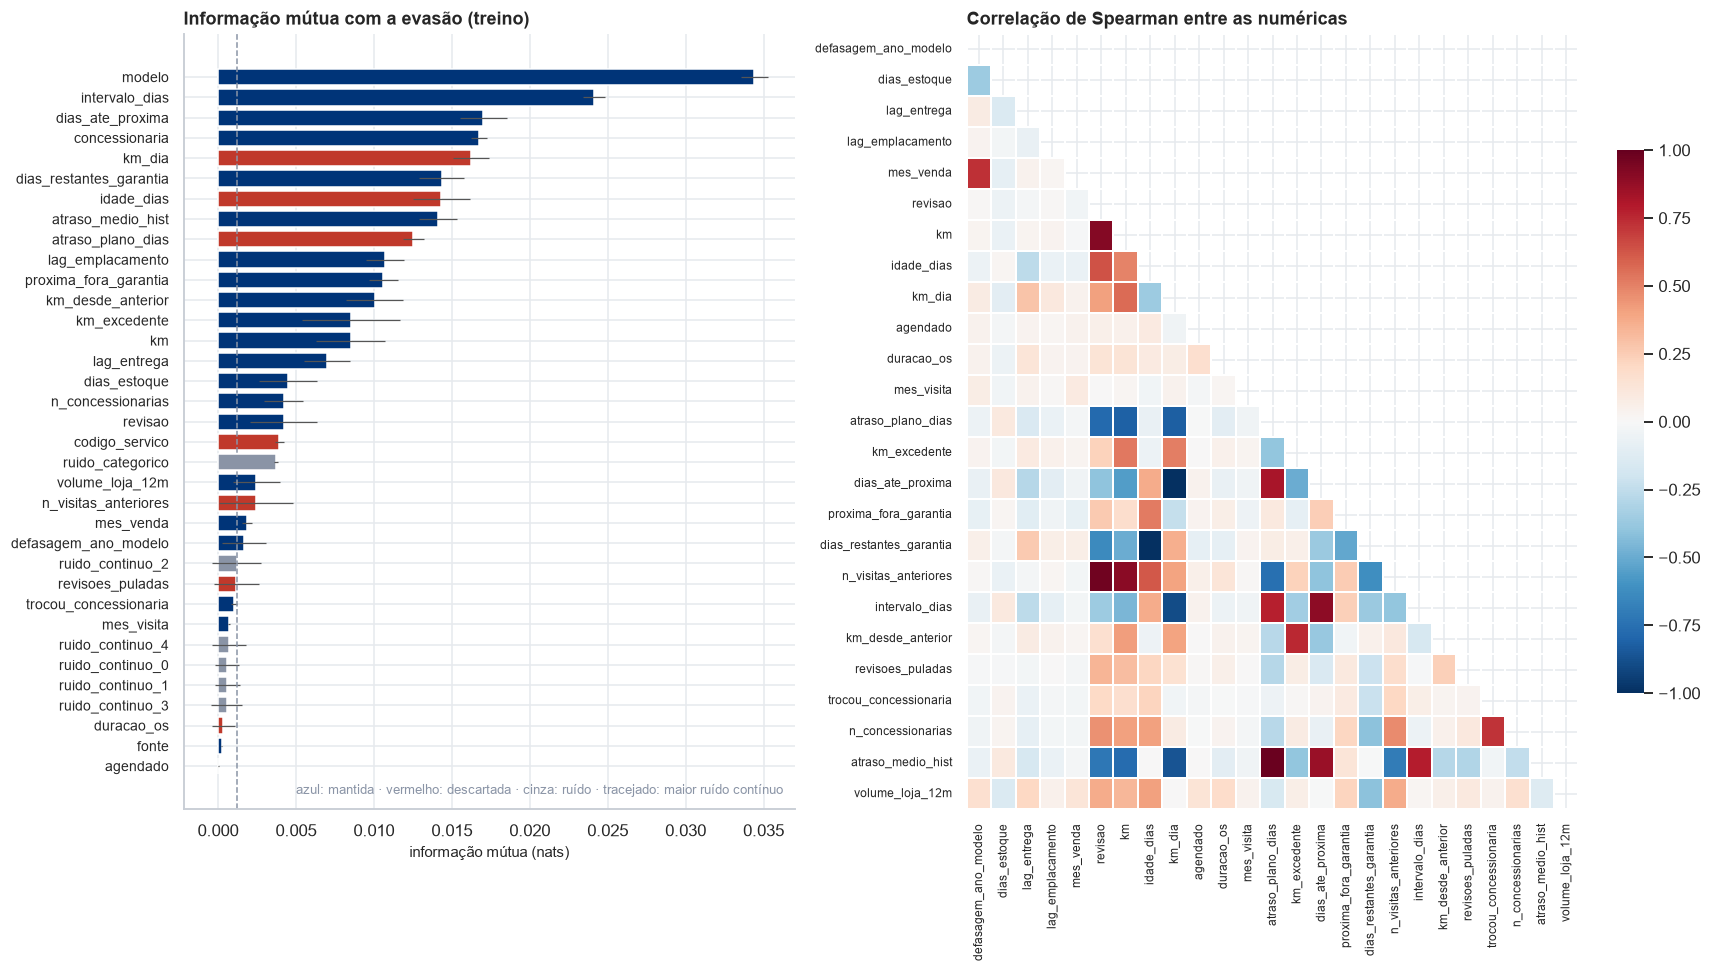

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={"width_ratios": [1, 1.25]})
cores = [CINZA if c.startswith("ruido") else (VERMELHO if c in descartar else AZUL) for c in mi.index]
ax[0].barh(mi.index[::-1], mi.values[::-1], xerr=mi_desvio[mi.index[::-1]].values, color=cores[::-1],
           error_kw=dict(ecolor="#555", lw=0.8))
ax[0].axvline(ref_cont, color=CINZA, ls="--", lw=1)
ax[0].set(title="Informação mútua com a evasão (treino)", xlabel="informação mútua (nats)")
ax[0].tick_params(axis="y", labelsize=9)
ax[0].text(0.98, 0.02, "azul: mantida · vermelho: descartada · cinza: ruído · tracejado: maior ruído contínuo",
           transform=ax[0].transAxes, ha="right", fontsize=8.5, color=CINZA)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[1],
            cbar_kws={"shrink": 0.7}, linewidths=0.3)
ax[1].set(title="Correlação de Spearman entre as numéricas")
ax[1].tick_params(labelsize=8)
plt.tight_layout(); salvar(fig, "05_selecao"); plt.show()

**Resultado da seleção**

- **Sem sinal acima do ruído:** `agendado` (94% das visitas são agendadas, e a evasão é praticamente igual com e sem agenda), `duracao_os`, `revisoes_puladas` e `codigo_servico`. O código de serviço tem 139 níveis e, descontado o viés de cardinalidade, não informa mais do que o número da revisão já informa.
- **Redundantes:** quatro pares carregam a mesma informação. `revisao` e `n_visitas_anteriores`; `idade_dias` e `dias_restantes_garantia` (uma é a outra invertida); `km_dia` e `dias_ate_proxima` (uma define a outra); `atraso_plano_dias` e a média histórica do atraso. Em cada par, sai a de menor informação mútua.
- A concessionária fica bem acima do ruído com o mesmo número de níveis. A loja carrega sinal real, e não só cardinalidade alta.
- Das 29 candidatas ficam **21**. A primeira versão desta seleção usava uma estimativa só, e o ruído de referência chegou a 0,004 por puro acaso, o que derrubava 9 variáveis úteis. A média de 5 repetições tirou essa instabilidade: as barras de erro no gráfico mostram a oscilação que sobra.

## 2.8 Transformação, normalização e padronização

Todo o pré-processamento fica dentro de um `Pipeline` do scikit-learn. O `fit` acontece só nos dados de treino de cada fold, e em produção o mesmo objeto é aplicado à visita nova.

| Tipo | Colunas | Tratamento |
|---|---|---|
| categóricas de baixa cardinalidade | `modelo`, `fonte`, `codigo_servico` | one-hot; categorias com menos de 500 casos viram "infrequente" |
| alta cardinalidade | `concessionaria` (435 lojas) | *target encoding* com validação cruzada interna, para a loja não "decorar" o próprio alvo |
| numéricas assimétricas | as não negativas em que o `log1p` reduz a assimetria (medido no treino) | mediana para faltantes + indicador de faltante, `log1p`, padronização |
| demais numéricas | atrasos, flags, meses | mediana + indicador de faltante, padronização |

A padronização pesa para Regressão Logística, KNN e MLP, que usam distância ou gradiente. Para os modelos de árvore ela é neutra, mas manter o mesmo pré-processamento em todos deixa a comparação justa.

In [17]:
CAT_OH = [c for c in ["modelo", "fonte", "codigo_servico"] if c in FEATURES]
CAT_TE = [c for c in ["concessionaria"] if c in FEATURES]
# log1p só onde ele de fato reduz a assimetria (medido no treino)
NAO_NEGATIVAS = [c for c in FEATURES if c not in CAT_OH + CAT_TE and X_todas.loc[idx_treino, c].min() >= 0
                 and X_todas.loc[idx_treino, c].nunique() > 2]
assim = pd.DataFrame({"assimetria original": X_todas.loc[idx_treino, NAO_NEGATIVAS].skew(),
                      "assimetria com log1p": np.log1p(X_todas.loc[idx_treino, NAO_NEGATIVAS]).skew()})
assim["usa log1p"] = assim["assimetria com log1p"].abs() < assim["assimetria original"].abs()
NUM_LOG = assim.index[assim["usa log1p"]].tolist()
NUM_LIN = [c for c in FEATURES if c not in CAT_OH + CAT_TE + NUM_LOG]


def montar_preprocessador(colunas=None):
    colunas = set(colunas or FEATURES)
    so = lambda lista: [c for c in lista if c in colunas]
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=500, sparse_output=False), so(CAT_OH)),
        ("loja", TargetEncoder(target_type="binary", cv=5, shuffle=True, random_state=SEED), so(CAT_TE)),
        ("log", Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)),
                          ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("padronizar", StandardScaler())]), so(NUM_LOG)),
        ("num", Pipeline([("imputar", SimpleImputer(strategy="median", add_indicator=True)),
                          ("padronizar", StandardScaler())]), so(NUM_LIN)),
    ], verbose_feature_names_out=False)


X_tr, y_tr = X_todas.loc[idx_treino, FEATURES], y.loc[idx_treino]
X_te, y_te = X_todas.loc[idx_teste, FEATURES], y.loc[idx_teste]

prep = montar_preprocessador().fit(X_tr, y_tr)
nomes_saida = prep.get_feature_names_out()
print(f"{len(FEATURES)} colunas de entrada → {len(nomes_saida)} colunas numéricas depois do pré-processamento")
print(f"com log1p: {NUM_LOG}")
assim.round(2).sort_values("assimetria original", ascending=False)

21 colunas de entrada → 44 colunas numéricas depois do pré-processamento
com log1p: ['dias_estoque', 'lag_entrega', 'revisao', 'km', 'km_desde_anterior', 'n_concessionarias']


,assimetria original,assimetria com log1p,usa log1p
km_desde_anterior,20.6900,-7.9900,True
lag_entrega,17.4500,3.6500,True
revisao,2.7800,0.8900,True
km,2.7000,-0.1300,True
n_concessionarias,2.5100,1.7500,True
dias_estoque,1.9900,-0.7400,True
volume_loja_12m,1.1700,-1.2200,False
intervalo_dias,0.9700,-1.0300,False
dias_ate_proxima,0.2200,-0.5400,False
mes_venda,0.0800,-0.5100,False


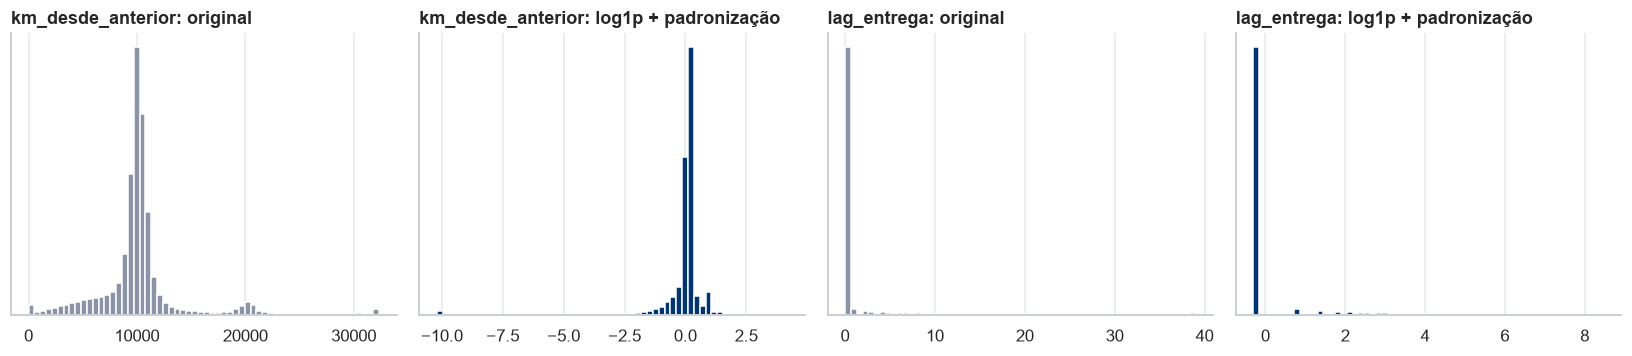

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for i, c in enumerate(assim[assim["usa log1p"]].sort_values("assimetria original", ascending=False).index[:2]):
    bruto_c = X_tr[c].dropna()
    ax[2 * i].hist(bruto_c.clip(upper=bruto_c.quantile(0.995)), bins=60, color=CINZA)
    ax[2 * i].set(title=f"{c}: original", yticks=[])
    ax[2 * i + 1].hist(StandardScaler().fit_transform(np.log1p(bruto_c.values.reshape(-1, 1))).ravel(), bins=60, color=AZUL)
    ax[2 * i + 1].set(title=f"{c}: log1p + padronização", yticks=[])
plt.tight_layout(); salvar(fig, "06_transformacao"); plt.show()

---
# 3. Desenvolvimento dos modelos

## 3.1 Algoritmos e justificativa

| Modelo | Família | Por que entra na comparação |
|---|---|---|
| Baseline (Dummy) | nenhuma | referência mínima: prevê a proporção do treino para todo mundo. Qualquer modelo útil precisa superá-lo |
| Regressão Logística | linear | interpretável e rápida; mostra quanto do problema é linear |
| KNN | baseado em instâncias | não assume forma nenhuma; testa se clientes "parecidos" se comportam igual |
| Árvore de Decisão | árvore | regras legíveis para o negócio; permite ver o sobreajuste variando a profundidade |
| Random Forest | ensemble (bagging) | reduz a variância da árvore, captura interações |
| XGBoost | ensemble (boosting) | referência em dados tabulares; lida bem com faltantes e interações |
| MLP | rede neural | camadas densas com regularização L2 e parada antecipada |

## 3.2 Protocolo

- **Busca de hiperparâmetros** numa amostra de ~60 mil visitas do treino, sorteada por **VIN**, com 5 folds agrupados por veículo. A busca completa em 250 mil visitas, para 7 algoritmos, levaria horas sem mudar a escolha; a seção 3.11 treina o modelo escolhido na base inteira e mede o ganho.
- **Métrica de seleção: ROC-AUC.** O uso do modelo é ordenar a fila do consultor, e a ROC-AUC mede exatamente a qualidade dessa ordenação, sem depender de limiar. PR-AUC, F1 e acurácia balanceada são registradas junto.
- *Grid search* para os espaços pequenos e *random search* para Random Forest e XGBoost, cujos espaços são grandes demais para varrer inteiros.
- O desbalanceamento (cerca de 1 evasão para 2 retornos) é tratado como hiperparâmetro: `class_weight` ou `scale_pos_weight` entram na busca, e a validação decide se ajudam.

In [19]:
vins_treino = pd.Series(vis.loc[idx_treino, "vin"].unique())
vins_busca = set(vins_treino.sample(frac=60_000 / len(idx_treino), random_state=SEED))
idx_busca = idx_treino[vis.loc[idx_treino, "vin"].isin(vins_busca)]
X_b, y_b, g_b = X_tr.loc[idx_busca], y_tr.loc[idx_busca], vis.loc[idx_busca, "vin"]
print(f"amostra de busca: {len(idx_busca):,} visitas de {len(vins_busca):,} veículos · evasão {y_b.mean():.1%}")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
METRICAS = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1", "acc_bal": "balanced_accuracy"}
buscas = {}


def buscar(nome, estimador, grade, n_iter=None):
    pipe = Pipeline([("prep", montar_preprocessador()), ("clf", estimador)])
    grade = {f"clf__{k}": v for k, v in grade.items()}
    comum = dict(scoring=METRICAS, refit="roc_auc", cv=cv, n_jobs=N_JOBS, return_train_score=True)
    busca = (RandomizedSearchCV(pipe, grade, n_iter=n_iter, random_state=SEED, **comum) if n_iter
             else GridSearchCV(pipe, grade, **comum))
    t0 = time.time()
    busca.fit(X_b, y_b, groups=g_b)
    busca.segundos_ = time.time() - t0
    buscas[nome] = busca
    r, i = busca.cv_results_, busca.best_index_
    print(f"{nome}: ROC-AUC na validação {r['mean_test_roc_auc'][i]:.4f} ± {r['std_test_roc_auc'][i]:.4f} "
          f"· {len(r['params'])} configurações × 5 folds em {busca.segundos_:.0f}s")
    print("melhores parâmetros:", {k.replace("clf__", ""): v for k, v in busca.best_params_.items()})
    return busca


def top_configs(busca, n=5):
    r = pd.DataFrame(busca.cv_results_)
    params = [c for c in r.columns if c.startswith("param_")]
    t = r[params + ["mean_test_roc_auc", "std_test_roc_auc", "mean_train_roc_auc", "mean_test_pr_auc",
                    "mean_test_f1", "mean_fit_time"]].copy()
    t.columns = [c.replace("param_clf__", "") for c in params] + [
        "val ROC-AUC", "desvio", "treino ROC-AUC", "val PR-AUC", "val F1", "segundos/fit"]
    return t.sort_values("val ROC-AUC", ascending=False).head(n).reset_index(drop=True)

amostra de busca: 59,803 visitas de 23,245 veículos · evasão 33.5%


## 3.3 Baseline

In [20]:
buscar("Baseline (Dummy)", DummyClassifier(), {"strategy": ["prior", "stratified"]})
top_configs(buscas["Baseline (Dummy)"])

Baseline (Dummy): ROC-AUC na validação 0.5000 ± 0.0000 · 2 configurações × 5 folds em 10s
melhores parâmetros: {'strategy': 'prior'}


,strategy,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,prior,0.5000,0.0000,0.5000,0.3349,0.0000,0.3575
1,stratified,0.4980,0.0053,0.4999,0.3340,0.3347,0.3219


## 3.4 Regressão Logística

Variamos a força da regularização `C` (menor = mais regularizado) e o balanceamento de classes.

In [21]:
buscar("Regressão Logística", LogisticRegression(max_iter=3000),
       {"C": [0.001, 0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]})
top_configs(buscas["Regressão Logística"], 10)

Regressão Logística: ROC-AUC na validação 0.6995 ± 0.0039 · 10 configurações × 5 folds em 16s
melhores parâmetros: {'C': 1, 'class_weight': 'balanced'}


,C,class_weight,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,1.0000,balanced,0.6995,0.0039,0.7066,0.5285,0.5554,0.8225
1,0.1000,balanced,0.6994,0.0040,0.7062,0.5285,0.5552,0.7883
2,10.0000,balanced,0.6994,0.0039,0.7066,0.5285,0.5551,0.7041
3,0.1000,NaN,0.6993,0.0041,0.7061,0.5289,0.3464,0.8785
4,1.0000,NaN,0.6993,0.0040,0.7065,0.5289,0.3507,0.8365
5,10.0000,NaN,0.6993,0.0040,0.7066,0.5289,0.3516,0.7842
6,0.0100,balanced,0.6977,0.0046,0.7023,0.5264,0.5555,0.8569
7,0.0100,NaN,0.6975,0.0046,0.7019,0.5267,0.3283,0.8246
8,0.0010,balanced,0.6893,0.0048,0.6910,0.5168,0.5450,0.5221
9,0.0010,NaN,0.6888,0.0047,0.6904,0.5166,0.2945,0.5251


A regularização quase não pesa: de `C = 0,01` a `C = 10`, a ROC-AUC fica entre 0,697 e 0,700, e só o extremo `C = 0,001` perde sinal. O balanceamento não muda a ordenação (a ROC-AUC é a mesma com e sem `class_weight`), mas o F1 no limiar 0,5 sobe de 0,35 para 0,56. Balancear só desloca as probabilidades para cima; a qualidade da fila continua igual. A seção 4.3 trata o limiar do jeito certo.

A distância entre treino (0,707) e validação (0,700) é mínima. O modelo linear não sobreajusta, mas também não tem como capturar interações como "idade alta **e** uso baixo".

## 3.5 KNN

O número de vizinhos controla o viés/variância: poucos vizinhos decoram o treino, muitos suavizam demais.

KNN: ROC-AUC na validação 0.6788 ± 0.0037 · 8 configurações × 5 folds em 269s
melhores parâmetros: {'n_neighbors': 151, 'weights': 'distance'}


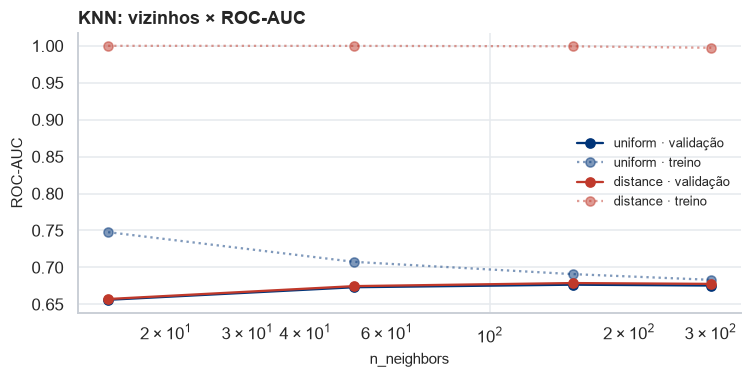

,n_neighbors,weights,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,151,distance,0.6788,0.0037,0.9993,0.5065,0.2719,0.3395
1,301,distance,0.6777,0.0042,0.9973,0.5031,0.2608,0.4293
2,151,uniform,0.6766,0.0037,0.6909,0.5006,0.2668,0.3988
3,301,uniform,0.6754,0.0044,0.6832,0.4980,0.2578,0.3993
4,51,distance,0.6747,0.0032,0.9999,0.5029,0.3221,0.3453


In [22]:
buscar("KNN", KNeighborsClassifier(n_jobs=1),
       {"n_neighbors": [15, 51, 151, 301], "weights": ["uniform", "distance"]})

r = pd.DataFrame(buscas["KNN"].cv_results_)
fig, ax = plt.subplots(figsize=(7, 3.6))
for w, cor in [("uniform", AZUL), ("distance", VERMELHO)]:
    s = r[r["param_clf__weights"] == w].sort_values("param_clf__n_neighbors")
    ax.plot(s["param_clf__n_neighbors"], s["mean_test_roc_auc"], "o-", color=cor, label=f"{w} · validação")
    ax.plot(s["param_clf__n_neighbors"], s["mean_train_roc_auc"], "o:", color=cor, alpha=0.5, label=f"{w} · treino")
ax.set(title="KNN: vizinhos × ROC-AUC", xlabel="n_neighbors", ylabel="ROC-AUC", xscale="log")
ax.legend(fontsize=8.5)
plt.tight_layout(); salvar(fig, "07_knn"); plt.show()
top_configs(buscas["KNN"])

Com peso por distância, o KNN tira ROC-AUC de 0,999 no treino, porque cada ponto é o vizinho mais próximo de si mesmo. Isso é memorização pura, mas a validação (0,679 com 151 vizinhos) mostra que ela não prejudica a generalização aqui. A partir de ~50 vizinhos a curva praticamente estabiliza. É o pior dos modelos reais: numa base com 44 dimensões depois do one-hot, "parecido" em distância euclidiana diz pouco sobre comportamento.

## 3.6 Árvore de Decisão

Árvore de Decisão: ROC-AUC na validação 0.6920 ± 0.0015 · 36 configurações × 5 folds em 48s
melhores parâmetros: {'class_weight': None, 'max_depth': 12, 'min_samples_leaf': 200}


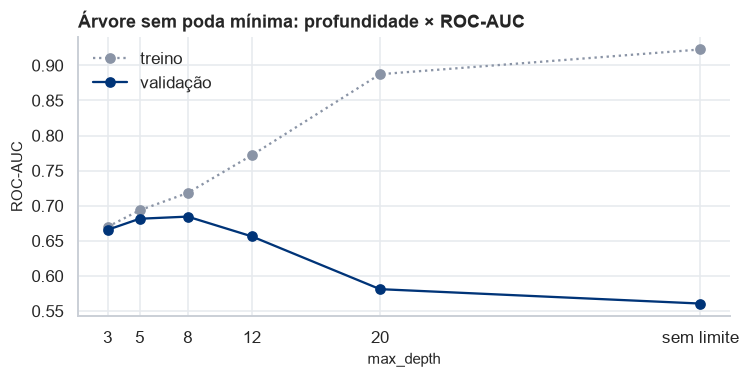

,class_weight,max_depth,min_samples_leaf,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,NaN,12,200,0.6920,0.0015,0.7176,0.5157,0.3903,0.9114
1,balanced,12,200,0.6918,0.0027,0.7177,0.5164,0.5395,1.0177
2,NaN,8,200,0.6913,0.0037,0.7075,0.5086,0.3599,0.7548
3,balanced,8,200,0.6910,0.0025,0.7082,0.5097,0.5365,1.1889
4,NaN,20,200,0.6908,0.0017,0.7223,0.5163,0.3963,0.9321


In [23]:
buscar("Árvore de Decisão", DecisionTreeClassifier(random_state=SEED),
       {"max_depth": [3, 5, 8, 12, 20, None], "min_samples_leaf": [1, 50, 200], "class_weight": [None, "balanced"]})

r = pd.DataFrame(buscas["Árvore de Decisão"].cv_results_)
s = r[(r["param_clf__min_samples_leaf"] == 1) & (r["param_clf__class_weight"].isna())].copy()
s["prof"] = s["param_clf__max_depth"].fillna(40).astype(int)
s = s.sort_values("prof")
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(s["prof"], s["mean_train_roc_auc"], "o:", color=CINZA, label="treino")
ax.plot(s["prof"], s["mean_test_roc_auc"], "o-", color=AZUL, label="validação")
ax.set_xticks(s["prof"], [str(p) if p < 40 else "sem limite" for p in s["prof"]])
ax.set(title="Árvore sem poda mínima: profundidade × ROC-AUC", xlabel="max_depth", ylabel="ROC-AUC")
ax.legend()
plt.tight_layout(); salvar(fig, "08_arvore"); plt.show()
top_configs(buscas["Árvore de Decisão"])

O gráfico mostra o sobreajuste de livro-texto. Sem tamanho mínimo de folha, a validação chega ao pico entre profundidade 5 e 8 e depois despenca até 0,56, enquanto o treino sobe para 0,92: a árvore passa a decorar visitas individuais. A melhor configuração (profundidade 12 com `min_samples_leaf = 200`) mostra a outra forma de controlar a complexidade, que é exigir pelo menos 200 visitas em cada folha. Com isso a árvore pode ser mais funda sem decorar.

## 3.7 Random Forest

In [24]:
buscar("Random Forest", RandomForestClassifier(n_jobs=1, random_state=SEED),
       {"n_estimators": [200], "max_depth": [8, 12, 16, 24], "min_samples_leaf": [5, 20, 50],
        "max_features": ["sqrt", 0.4], "class_weight": [None, "balanced_subsample"]}, n_iter=12)
top_configs(buscas["Random Forest"])

Random Forest: ROC-AUC na validação 0.7094 ± 0.0041 · 12 configurações × 5 folds em 252s
melhores parâmetros: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 16, 'class_weight': None}


,n_estimators,min_samples_leaf,max_features,max_depth,class_weight,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,200,5,sqrt,16,NaN,0.7094,0.0041,0.8651,0.5428,0.3836,18.5149
1,200,20,0.4000,16,balanced_subsample,0.7093,0.0045,0.8160,0.5422,0.5499,39.5138
2,200,20,sqrt,24,NaN,0.7092,0.0033,0.8116,0.5428,0.3830,17.4438
3,200,20,sqrt,16,balanced_subsample,0.7092,0.0038,0.7938,0.5423,0.5534,17.5460
4,200,20,sqrt,24,balanced_subsample,0.7090,0.0041,0.8134,0.5421,0.5503,18.2525


A Random Forest melhora a árvore única em ~0,02 de ROC-AUC (0,709 contra 0,692), o ganho esperado do *bagging*. O treino chega a 0,865, com a maior distância para a validação entre os modelos competitivos: as árvores individuais são fundas (profundidade 16, folhas de 5). A média de 200 delas controla a variância, mas o modelo fica pesado. Foi a busca mais cara (4 min para 12 configurações).

## 3.8 XGBoost

In [25]:
buscar("XGBoost", XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=1, random_state=SEED),
       {"n_estimators": [200, 400, 800], "learning_rate": [0.03, 0.06, 0.1], "max_depth": [4, 6, 8],
        "min_child_weight": [1, 5, 20], "subsample": [0.7, 0.9], "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [1, 5], "scale_pos_weight": [1, 1.9]}, n_iter=24)
top_configs(buscas["XGBoost"])

XGBoost: ROC-AUC na validação 0.7118 ± 0.0041 · 24 configurações × 5 folds em 182s
melhores parâmetros: {'subsample': 0.9, 'scale_pos_weight': 1, 'reg_lambda': 5, 'n_estimators': 800, 'min_child_weight': 20, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}


,subsample,scale_pos_weight,reg_lambda,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,0.9000,1.0000,5,800,20,4,0.0300,0.6000,0.7118,0.0041,0.7487,0.5486,0.4041,6.2606
1,0.9000,1.9000,5,400,20,6,0.0300,0.6000,0.7114,0.0043,0.7661,0.5486,0.5527,4.6396
2,0.9000,1.0000,1,200,20,6,0.0300,1.0000,0.7112,0.0041,0.7482,0.5477,0.3944,2.5491
3,0.9000,1.9000,1,200,5,6,0.0300,0.6000,0.7109,0.0045,0.7567,0.5469,0.5524,2.6867
4,0.7000,1.9000,5,200,1,4,0.1000,0.6000,0.7104,0.0038,0.7494,0.5471,0.5518,2.1894


O XGBoost vence com uma configuração **conservadora**: árvores rasas (profundidade 4), taxa de aprendizado baixa (0,03) compensada por 800 árvores, `min_child_weight = 20`, amostragem de 90% das linhas e 60% das colunas por árvore e regularização L2 (`reg_lambda = 5`). Tudo isso segura o sobreajuste: treino 0,749 contra validação 0,712. As cinco melhores configurações ficam a menos de 0,002 umas das outras, então o resultado não depende de um ajuste fino frágil.

## 3.9 MLP (rede neural)

Rede densa com ativação ReLU, otimizador Adam e parada antecipada (10% do treino de cada fold separado para monitorar a perda). Variamos a arquitetura e a regularização L2 (`alpha`).

MLP (rede neural): ROC-AUC na validação 0.7002 ± 0.0043 · 12 configurações × 5 folds em 101s
melhores parâmetros: {'alpha': 0.01, 'hidden_layer_sizes': (32,)}


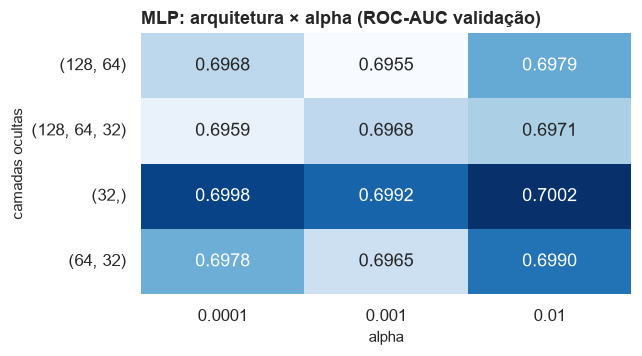

,alpha,hidden_layer_sizes,val ROC-AUC,desvio,treino ROC-AUC,val PR-AUC,val F1,segundos/fit
0,0.0100,"(32,)",0.7002,0.0043,0.7148,0.5323,0.3806,5.2747
1,0.0001,"(32,)",0.6998,0.0044,0.7159,0.5328,0.3764,4.4435
2,0.0010,"(32,)",0.6992,0.0039,0.7173,0.5315,0.3820,6.0196
3,0.0100,"(64, 32)",0.6990,0.0054,0.7229,0.5323,0.3796,7.6746
4,0.0100,"(128, 64)",0.6979,0.0028,0.7235,0.5293,0.3794,11.4254


In [26]:
buscar("MLP (rede neural)", MLPClassifier(early_stopping=True, max_iter=300, random_state=SEED),
       {"hidden_layer_sizes": [(32,), (64, 32), (128, 64), (128, 64, 32)], "alpha": [1e-4, 1e-3, 1e-2]})

r = pd.DataFrame(buscas["MLP (rede neural)"].cv_results_)
piv = r.assign(arq=r["param_clf__hidden_layer_sizes"].astype(str)).pivot_table(
    index="arq", columns="param_clf__alpha", values="mean_test_roc_auc")
fig, ax = plt.subplots(figsize=(6, 3.4))
sns.heatmap(piv, annot=True, fmt=".4f", cmap="Blues", ax=ax, cbar=False)
ax.set(title="MLP: arquitetura × alpha (ROC-AUC validação)", xlabel="alpha", ylabel="camadas ocultas")
plt.tight_layout(); salvar(fig, "09_mlp"); plt.show()
top_configs(buscas["MLP (rede neural)"])

A arquitetura quase não importa: as cinco melhores combinações ficam entre 0,698 e 0,700, e a melhor é a menor rede (uma camada de 32 neurônios). Mais camadas e mais neurônios não acrescentam nada. O limite está na informação que as 21 variáveis carregam, não na capacidade do modelo de representá-la. Em dados tabulares desse tamanho, é o resultado esperado para redes densas diante do boosting.

## 3.10 Comparação na validação cruzada

Cada linha é a **melhor configuração** de cada algoritmo. A coluna de sobreajuste mostra a distância entre o desempenho no treino e na validação.

melhor na validação: XGBoost


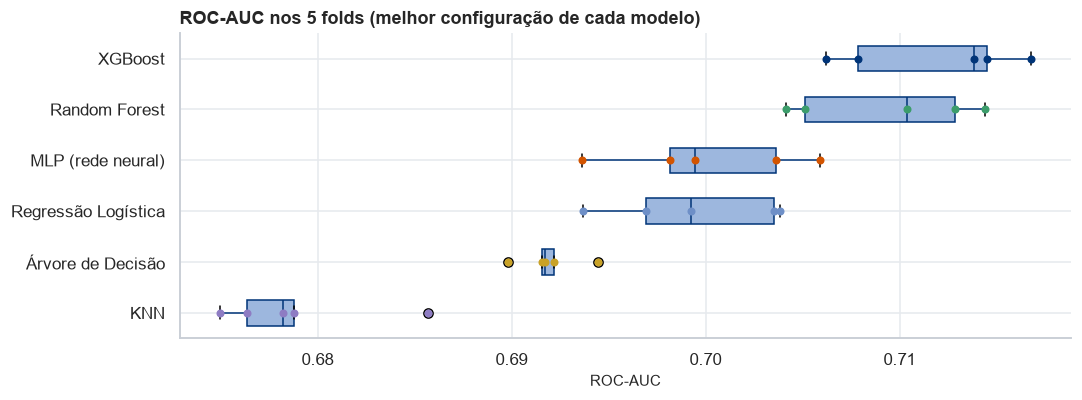

,val ROC-AUC,desvio,treino ROC-AUC,sobreajuste,val PR-AUC,val F1,val acc. bal.,configurações,busca (s)
modelo,,,,,,,,,
XGBoost,0.7118,0.0041,0.7487,0.0369,0.5486,0.4041,0.6022,24,182
Random Forest,0.7094,0.0041,0.8651,0.1557,0.5428,0.3836,0.5952,12,252
MLP (rede neural),0.7002,0.0043,0.7148,0.0147,0.5323,0.3806,0.5921,12,101
Regressão Logística,0.6995,0.0039,0.7066,0.0072,0.5285,0.5554,0.6406,10,16
Árvore de Decisão,0.6920,0.0015,0.7176,0.0257,0.5157,0.3903,0.5926,36,48
KNN,0.6788,0.0037,0.9993,0.3205,0.5065,0.2719,0.5595,8,269
Baseline (Dummy),0.5000,0.0000,0.5000,0.0000,0.3349,0.0000,0.5000,2,10


In [27]:
linhas, folds = [], {}
for nome, b in buscas.items():
    r, i = b.cv_results_, b.best_index_
    linhas.append({"modelo": nome, "val ROC-AUC": r["mean_test_roc_auc"][i], "desvio": r["std_test_roc_auc"][i],
                   "treino ROC-AUC": r["mean_train_roc_auc"][i], "val PR-AUC": r["mean_test_pr_auc"][i],
                   "val F1": r["mean_test_f1"][i], "val acc. bal.": r["mean_test_acc_bal"][i],
                   "configurações": len(r["params"]), "busca (s)": round(b.segundos_)})
    folds[nome] = [r[f"split{k}_test_roc_auc"][i] for k in range(5)]
comp_cv = pd.DataFrame(linhas).set_index("modelo").sort_values("val ROC-AUC", ascending=False)
comp_cv.insert(3, "sobreajuste", comp_cv["treino ROC-AUC"] - comp_cv["val ROC-AUC"])
ESCOLHIDO = comp_cv.drop("Baseline (Dummy)").index[0]
print(f"melhor na validação: {ESCOLHIDO}")

fig, ax = plt.subplots(figsize=(10, 3.8))
ordem = [m for m in comp_cv.index if m != "Baseline (Dummy)"][::-1]
ax.boxplot([folds[m] for m in ordem], vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=AZUL_CLARO, color=AZUL), medianprops=dict(color=AZUL), whiskerprops=dict(color=AZUL))
for k, m in enumerate(ordem, start=1):
    ax.scatter(folds[m], [k] * 5, color=CORES[m], s=18, zorder=3)
ax.set_yticks(range(1, len(ordem) + 1), ordem)
ax.set(title="ROC-AUC nos 5 folds (melhor configuração de cada modelo)", xlabel="ROC-AUC")
plt.tight_layout(); salvar(fig, "10_comparacao_cv"); plt.show()
comp_cv

**Leitura da comparação**

- **XGBoost (0,712) e Random Forest (0,709)** lideram, com diferença menor que o desvio entre folds (0,004). Na validação eles praticamente empatam.
- **MLP e Regressão Logística** empatam em ~0,700. Logo, a não linearidade que a MLP consegue capturar é pequena, e os ensembles de árvores capturam mais.
- O **sobreajuste** separa os dois líderes: 0,037 no XGBoost contra 0,156 na Random Forest. O boosting regularizado chega ao mesmo lugar com um modelo mais simples, menor e mais rápido de pontuar.
- Todos superam o baseline por larga margem, e os desvios entre folds são baixos (≤ 0,005), então a comparação é estável.

Seguimos com o **XGBoost**: melhor média, menor sobreajuste entre os competitivos e artefato leve para servir no `ml-api`.

## 3.11 Ajuste fino do modelo escolhido

Com o XGBoost à frente, testamos mais configurações em torno do melhor ponto da busca aleatória:

1. **taxa de aprendizado × número de árvores**, o par que mais mexe no boosting;
2. **profundidade × `scale_pos_weight`**: complexidade de cada árvore e peso da classe minoritária;
3. **grupos de variáveis** (ablação), para medir quanto cada tipo de informação contribui, inclusive quanto o dado da venda (D0) sozinho consegue;
4. **curva de aprendizado**, para decidir se vale treinar na base inteira.

Os itens 3 e 4 usam uma **validação temporal dentro do treino**: ajuste com o que já era conhecido em 01/07/2023, avaliação nas visitas de 07/2023 a 06/2024. O teste continua intocado.

26 configurações extras em 337s


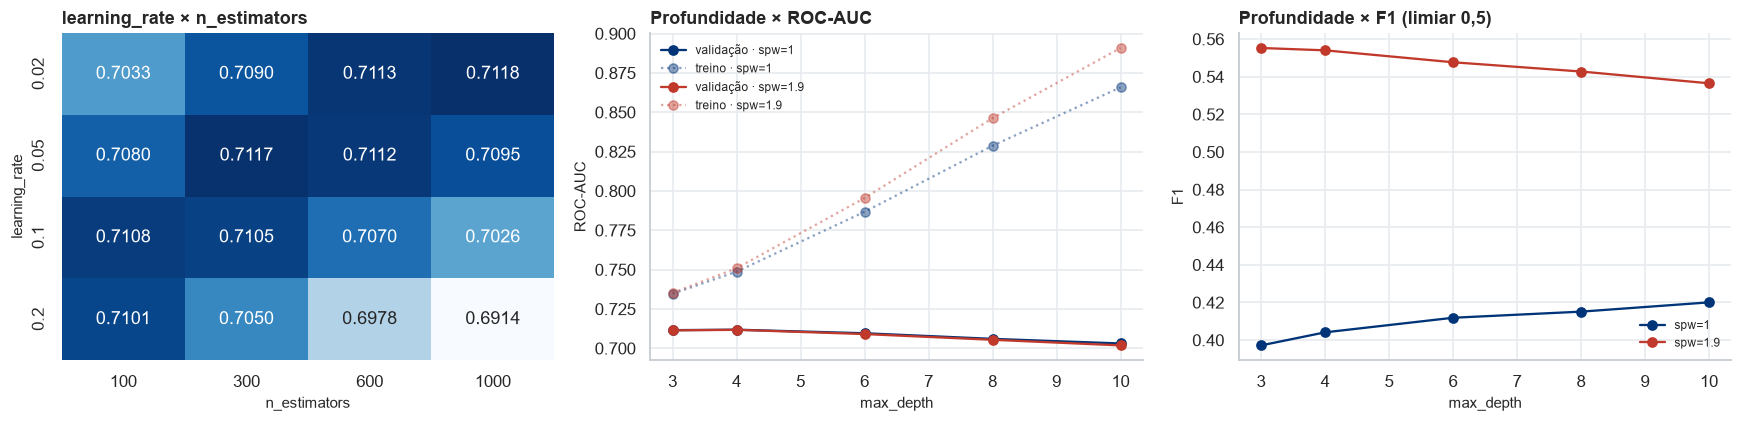

melhor ROC-AUC na validação: 0.7118
configuração final: {'subsample': 0.9, 'scale_pos_weight': 1, 'reg_lambda': 5, 'n_estimators': 1000, 'min_child_weight': 20, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.6}


In [28]:
base_xgb = buscas["XGBoost"].best_estimator_
melhores = {k.replace("clf__", ""): v for k, v in buscas["XGBoost"].best_params_.items()}


def grade_local(grade):
    b = GridSearchCV(clone(base_xgb), {f"clf__{k}": v for k, v in grade.items()}, scoring=METRICAS,
                     refit="roc_auc", cv=cv, n_jobs=N_JOBS, return_train_score=True)
    return b.fit(X_b, y_b, groups=g_b)


t0 = time.time()
g1 = grade_local({"learning_rate": [0.02, 0.05, 0.1, 0.2], "n_estimators": [100, 300, 600, 1000]})
g2 = grade_local({"max_depth": [3, 4, 6, 8, 10], "scale_pos_weight": [1, 1.9]})
print(f"{len(g1.cv_results_['params']) + len(g2.cv_results_['params'])} configurações extras em {time.time() - t0:.0f}s")

r1, r2 = pd.DataFrame(g1.cv_results_), pd.DataFrame(g2.cv_results_)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
piv = r1.pivot_table(index="param_clf__learning_rate", columns="param_clf__n_estimators", values="mean_test_roc_auc")
sns.heatmap(piv, annot=True, fmt=".4f", cmap="Blues", cbar=False, ax=ax[0])
ax[0].set(title="learning_rate × n_estimators", xlabel="n_estimators", ylabel="learning_rate")
for spw, cor in [(1, AZUL), (1.9, VERMELHO)]:
    s = r2[r2["param_clf__scale_pos_weight"] == spw].sort_values("param_clf__max_depth")
    ax[1].plot(s["param_clf__max_depth"], s["mean_test_roc_auc"], "o-", color=cor, label=f"validação · spw={spw}")
    ax[1].plot(s["param_clf__max_depth"], s["mean_train_roc_auc"], "o:", color=cor, alpha=0.45, label=f"treino · spw={spw}")
    ax[2].plot(s["param_clf__max_depth"], s["mean_test_f1"], "o-", color=cor, label=f"spw={spw}")
ax[1].set(title="Profundidade × ROC-AUC", xlabel="max_depth", ylabel="ROC-AUC"); ax[1].legend(fontsize=8)
ax[2].set(title="Profundidade × F1 (limiar 0,5)", xlabel="max_depth", ylabel="F1"); ax[2].legend(fontsize=8)
plt.tight_layout(); salvar(fig, "11_xgb_ajuste"); plt.show()

candidatos = pd.concat([
    pd.DataFrame({"params": buscas["XGBoost"].cv_results_["params"], "auc": buscas["XGBoost"].cv_results_["mean_test_roc_auc"]}),
    pd.DataFrame({"params": g1.cv_results_["params"], "auc": g1.cv_results_["mean_test_roc_auc"]}),
    pd.DataFrame({"params": g2.cv_results_["params"], "auc": g2.cv_results_["mean_test_roc_auc"]}),
], ignore_index=True)
melhor_geral = candidatos.loc[candidatos["auc"].idxmax()]
PARAMS_FINAIS = {**{f"clf__{k}": v for k, v in melhores.items()}, **melhor_geral["params"]}
print(f"melhor ROC-AUC na validação: {melhor_geral['auc']:.4f}")
print("configuração final:", {k.replace("clf__", ""): v for k, v in PARAMS_FINAIS.items()})

**O que o ajuste fino mostrou**

- **Taxa × árvores:** há uma diagonal de configurações equivalentes (0,02 com 1.000 árvores ≈ 0,05 com 300 ≈ 0,1 com 100, todas perto de 0,711). Taxa alta com muitas árvores sobreajusta: 0,2 com 1.000 árvores cai para 0,691.
- **Profundidade:** 3 ou 4 é o melhor ponto. Com profundidade 10, o treino vai a 0,87–0,89 e a validação cai para 0,703. As interações úteis são de baixa ordem.
- **`scale_pos_weight`:** não muda a ROC-AUC (as duas curvas se sobrepõem), mas muda o F1 no limiar 0,5 de ~0,40 para ~0,55. Confirma o que a regressão logística já mostrava: o peso da classe só move o limiar, e o limiar é escolhido à parte (4.3).

Configuração final: `learning_rate = 0,02`, 1.000 árvores, profundidade 4, `min_child_weight = 20`, `subsample = 0,9`, `colsample_bytree = 0,6`, `reg_lambda = 5`, sem peso de classe.

validação temporal: ajuste com 161,042 visitas · avaliação em 23,210


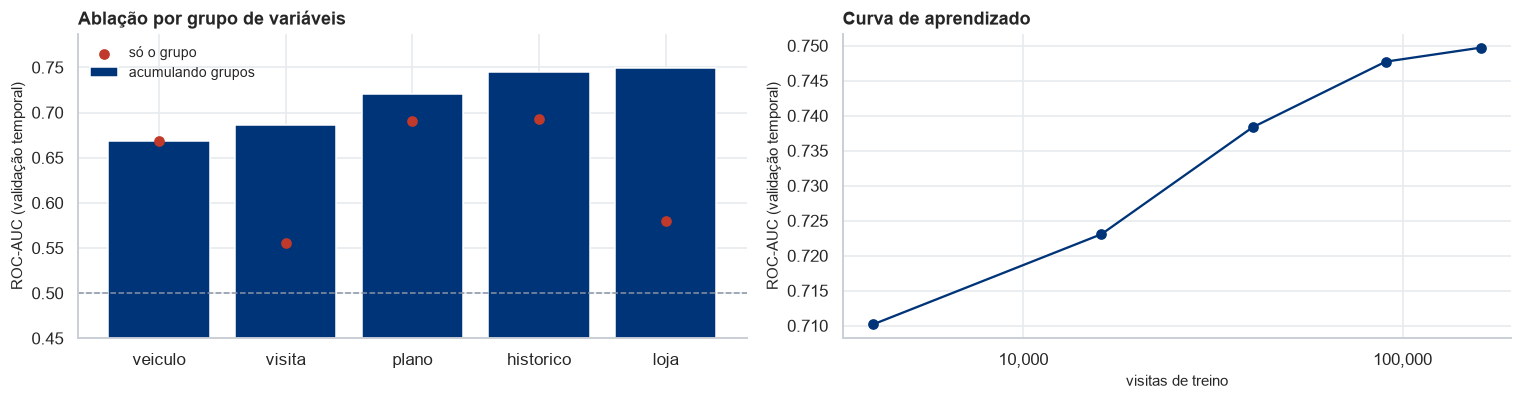

,features,ROC-AUC só o grupo,ROC-AUC acumulado,PR-AUC acumulado
grupo,,,,
veiculo,6,0.6681,0.6681,0.3931
visita,4,0.5550,0.6861,0.4175
plano,4,0.6903,0.7207,0.4702
historico,5,0.6924,0.7448,0.5129
loja,2,0.5794,0.7497,0.5145


,visitas de treino,ROC-AUC,PR-AUC
0,4013,0.7102,0.4463
1,16067,0.7231,0.4756
2,40222,0.7383,0.4999
3,90247,0.7477,0.5100
4,161042,0.7497,0.5145


In [29]:
CORTE_VAL = pd.Timestamp("2023-07-01")
idx_fit_v = idx_treino[(limite.loc[idx_treino] <= CORTE_VAL).values]
idx_val_v = idx_treino[(vis.loc[idx_treino, "data"] >= CORTE_VAL).values]
print(f"validação temporal: ajuste com {len(idx_fit_v):,} visitas · avaliação em {len(idx_val_v):,}")


def xgb_final(colunas=None):
    pipe = Pipeline([("prep", montar_preprocessador(colunas)),
                     ("clf", XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=SEED))])
    return pipe.set_params(**PARAMS_FINAIS).set_params(clf__n_jobs=-1)


def avaliar_val(colunas, idx_fit):
    m = xgb_final(colunas).fit(X_todas.loc[idx_fit, colunas], y.loc[idx_fit])
    s = m.predict_proba(X_todas.loc[idx_val_v, colunas])[:, 1]
    return roc_auc_score(y.loc[idx_val_v], s), average_precision_score(y.loc[idx_val_v], s)


ablacao, acumulado = [], []
for grupo, cols in fr.GRUPOS.items():
    cols = [c for c in cols if c in FEATURES]
    acumulado += cols
    so_grupo = avaliar_val(cols, idx_fit_v)
    ate_aqui = avaliar_val(list(acumulado), idx_fit_v)
    ablacao.append({"grupo": grupo, "features": len(cols), "ROC-AUC só o grupo": so_grupo[0],
                    "ROC-AUC acumulado": ate_aqui[0], "PR-AUC acumulado": ate_aqui[1]})
ablacao = pd.DataFrame(ablacao).set_index("grupo")

rng = np.random.default_rng(SEED)
vins_fit = vis.loc[idx_fit_v, "vin"].unique()
curva = []
for n_vins in [2_000, 8_000, 20_000, 45_000, len(vins_fit)]:
    escolhidos = set(rng.choice(vins_fit, size=min(n_vins, len(vins_fit)), replace=False))
    idx_n = idx_fit_v[vis.loc[idx_fit_v, "vin"].isin(escolhidos).values]
    auc, ap = avaliar_val(FEATURES, idx_n)
    curva.append({"visitas de treino": len(idx_n), "ROC-AUC": auc, "PR-AUC": ap})
curva = pd.DataFrame(curva)

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].bar(ablacao.index, ablacao["ROC-AUC acumulado"], color=AZUL, label="acumulando grupos")
ax[0].scatter(ablacao.index, ablacao["ROC-AUC só o grupo"], color=VERMELHO, zorder=3, label="só o grupo")
ax[0].axhline(0.5, color=CINZA, ls="--", lw=1)
ax[0].set(title="Ablação por grupo de variáveis", ylabel="ROC-AUC (validação temporal)", ylim=(0.45, None))
ax[0].legend(fontsize=9)
ax[1].plot(curva["visitas de treino"], curva["ROC-AUC"], "o-", color=AZUL)
ax[1].set(title="Curva de aprendizado", xlabel="visitas de treino", ylabel="ROC-AUC (validação temporal)", xscale="log")
ax[1].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); salvar(fig, "12_ablacao_curva"); plt.show()
display(ablacao)
curva

**Quanto cada tipo de informação vale** (validação temporal: ajuste com 161 mil visitas, avaliação em 23 mil de 07/2023 a 06/2024)

- **Só os dados do veículo, que existem desde a venda, dão 0,668.** É a resposta mais direta à pergunta D0 do PrevioPLS: modelo, estoque, entrega e emplacamento já separam risco bem acima do acaso. Um classificador na venda é viável, desde que haja uma base com os compradores que nunca voltaram (seção 5.5).
- Plano de revisão (+0,035) e histórico do VIN (+0,024) são os maiores ganhos incrementais. Sozinhos, cada um chega a ~0,69.
- Visita e loja isoladas valem pouco (0,555 e 0,579), mas somam no conjunto: o todo chega a **0,750**.
- **Curva de aprendizado:** de 4 mil para 161 mil visitas, a ROC-AUC sobe de 0,710 para 0,750, com ganho ainda positivo no fim (0,748 → 0,750 entre 90 e 161 mil). Por isso o modelo final treina nas 250 mil visitas do treino, e não só na amostra da busca.

In [30]:
t0 = time.time()
modelo_final = xgb_final().fit(X_tr, y_tr)
print(f"XGBoost final treinado em {len(X_tr):,} visitas em {time.time() - t0:.0f}s")

XGBoost final treinado em 250,383 visitas em 52s


---
# 4. Avaliação e comparação

## 4.1 Métricas escolhidas

| Métrica | O que responde | Por que importa aqui |
|---|---|---|
| **ROC-AUC** | sorteando um carro que evade e um que volta, qual a chance de o modelo dar mais risco ao primeiro? | é a qualidade da fila do consultor; não depende de limiar |
| **PR-AUC** | precisão média ao longo dos limiares | foca na classe positiva; a referência é a taxa de evasão (~35%), não 0,5 |
| **F1, precisão, recall** | acertos no limiar de decisão | decide quem vira lead; o limiar sai da validação, nunca do teste |
| **Acurácia balanceada** | média do acerto em cada classe | com 1 evasão para 2 retornos, a acurácia simples premia prever "volta" para todos |
| **Brier** | erro quadrático das probabilidades | a probabilidade aparece no app e precisa significar o que diz |

Todos os números abaixo são do **teste temporal** (visitas a partir de 07/2024), que nenhum modelo viu em nenhuma etapa.

## 4.2 Resultados no teste

In [31]:
def metricas(y_true, score, limiar=0.5):
    pred = (score >= limiar).astype(int)
    return {"ROC-AUC": roc_auc_score(y_true, score), "PR-AUC": average_precision_score(y_true, score),
            "F1": f1_score(y_true, pred, zero_division=0), "precisão": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred), "acurácia bal.": balanced_accuracy_score(y_true, pred),
            "Brier": brier_score_loss(y_true, score)}


scores_teste = {}
for nome, b in buscas.items():
    est = b.best_estimator_
    if "n_jobs" in est.named_steps["clf"].get_params():
        est.set_params(clf__n_jobs=N_JOBS)
    scores_teste[nome] = est.predict_proba(X_te)[:, 1]
NOME_FINAL = "XGBoost final (treino completo)"
scores_teste[NOME_FINAL] = modelo_final.predict_proba(X_te)[:, 1]
CORES[NOME_FINAL] = VERMELHO

comp_teste = pd.DataFrame({n: metricas(y_te, s) for n, s in scores_teste.items()}).T.sort_values("ROC-AUC", ascending=False)
comp_teste.insert(0, "treinado em", [f"treino completo ({len(X_tr) / 1000:.0f} mil)" if n == NOME_FINAL
                                     else f"amostra ({len(X_b) / 1000:.0f} mil)" for n in comp_teste.index])
print(f"taxa de evasão no teste: {y_te.mean():.1%} (é o PR-AUC de um modelo aleatório)")
comp_teste

taxa de evasão no teste: 35.6% (é o PR-AUC de um modelo aleatório)


,treinado em,ROC-AUC,PR-AUC,F1,precisão,recall,acurácia bal.,Brier
XGBoost final (treino completo),treino completo (250 mil),0.6981,0.5470,0.2971,0.6162,0.1957,0.5641,0.2088
Random Forest,amostra (60 mil),0.6875,0.5285,0.2461,0.6066,0.1544,0.5495,0.2106
XGBoost,amostra (60 mil),0.6870,0.5364,0.3083,0.6114,0.2061,0.5668,0.2101
Árvore de Decisão,amostra (60 mil),0.6652,0.4985,0.2966,0.5736,0.2000,0.5589,0.2152
MLP (rede neural),amostra (60 mil),0.6562,0.5096,0.2651,0.6027,0.1699,0.5540,0.2268
Regressão Logística,amostra (60 mil),0.6238,0.4869,0.3950,0.5041,0.3248,0.5740,0.2262
KNN,amostra (60 mil),0.5715,0.4448,0.1952,0.5645,0.1180,0.5338,0.2416
Baseline (Dummy),amostra (60 mil),0.5000,0.3562,0.0000,0.0000,0.0000,0.5000,0.2298


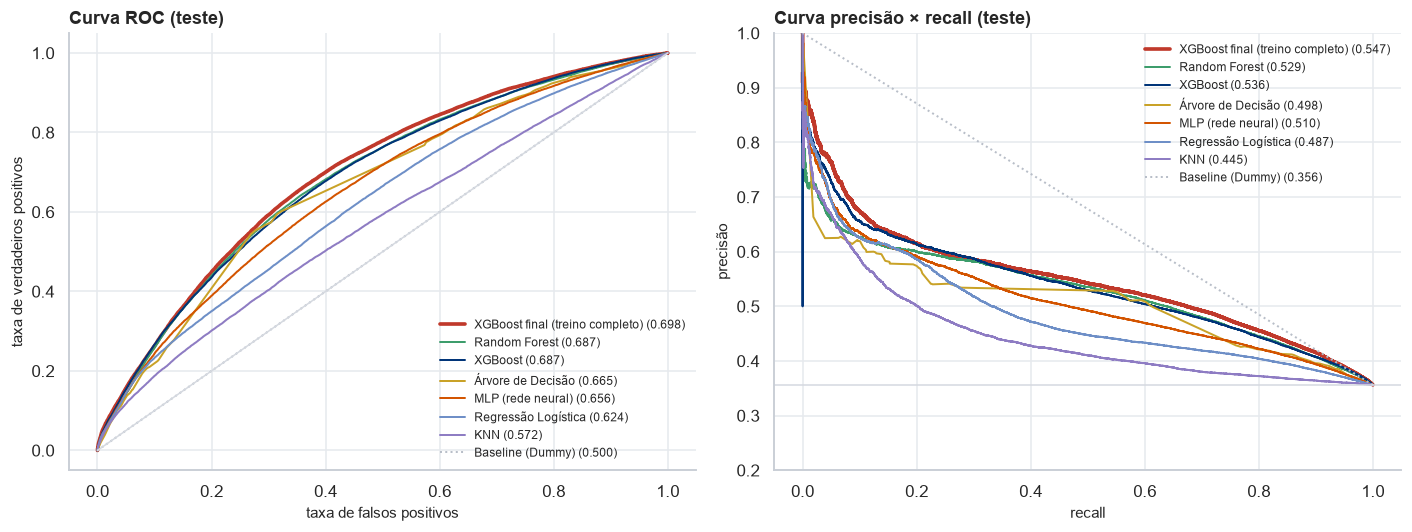

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for nome in comp_teste.index:
    s = scores_teste[nome]
    fpr, tpr, _ = roc_curve(y_te, s)
    prec, rec, _ = precision_recall_curve(y_te, s)
    estilo = dict(color=CORES[nome], lw=2.4 if nome == NOME_FINAL else 1.3,
                  ls=":" if nome == "Baseline (Dummy)" else "-")
    ax[0].plot(fpr, tpr, label=f"{nome} ({roc_auc_score(y_te, s):.3f})", **estilo)
    ax[1].plot(rec, prec, label=f"{nome} ({average_precision_score(y_te, s):.3f})", **estilo)
ax[0].plot([0, 1], [0, 1], color=CINZA_CLARO, lw=1)
ax[0].set(title="Curva ROC (teste)", xlabel="taxa de falsos positivos", ylabel="taxa de verdadeiros positivos")
ax[1].axhline(y_te.mean(), color=CINZA_CLARO, lw=1)
ax[1].set(title="Curva precisão × recall (teste)", xlabel="recall", ylabel="precisão", ylim=(0.2, 1.0))
ax[0].legend(fontsize=8, loc="lower right"); ax[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); salvar(fig, "13_roc_pr"); plt.show()

**Resultado no teste temporal**

- O **XGBoost treinado no treino completo** é o melhor em todas as métricas de ordenação: **ROC-AUC 0,698**, **PR-AUC 0,547** (contra 0,356 do acaso) e o menor Brier (0,209). Treinar na base completa, em vez da amostra, soma +0,011 de ROC-AUC, como a curva de aprendizado antecipava.
- O teste é mais difícil que a validação cruzada (0,712) e que a validação temporal (0,750): o período de 07/2024 a 01/2026 tem mais evasão (35,6% contra 33,4% no treino) e uma frota mais velha, com a safra de 2020 saindo da garantia. É a queda que se espera ao prever o futuro, e é o número honesto para apresentar.
- **Quem perde mais com o tempo são os modelos lineares e de distância.** A Regressão Logística cai de 0,700 na validação para 0,624 no teste e o KNN, de 0,679 para 0,572; a MLP perde 0,044. Os modelos de árvore perdem só 0,02 a 0,03. A explicação mais provável é a extrapolação: o teste traz veículos mais velhos e com intervalos maiores do que o treino viu. A árvore mantém nesses casos o valor da última folha, enquanto a reta da regressão e a distância do KNN seguem crescendo. Essa **robustez à mudança temporal** é um argumento a mais para o XGBoost.
- F1 e recall no limiar 0,5 estão baixos para todos porque 0,5 não é o limiar certo para um alvo com 35% de positivos. A seção seguinte resolve isso.

## 4.3 Limiar de decisão

Com 0,5 fixo, o F1 depende de como cada modelo foi calibrado, e isso não diz se ele serve. O limiar do modelo final é escolhido nas **previsões fora da amostra do treino** (validação cruzada em 3 folds agrupados por VIN), maximizando o F1. Depois ele é aplicado ao teste sem mudança.

As mesmas previsões fora da amostra definem as **faixas de prioridade** do PrevioPLS pelos percentis de risco: crítica (10% mais arriscados), alta (10% a 30%), média (30% a 60%) e baixa (restante).

previsões fora da amostra em 34s · ROC-AUC OOF 0.7174
limiar que maximiza o F1 no treino: 0.295
cortes das faixas: {'CRITICA': 0.57, 'ALTA': 0.407, 'MEDIA': 0.291}


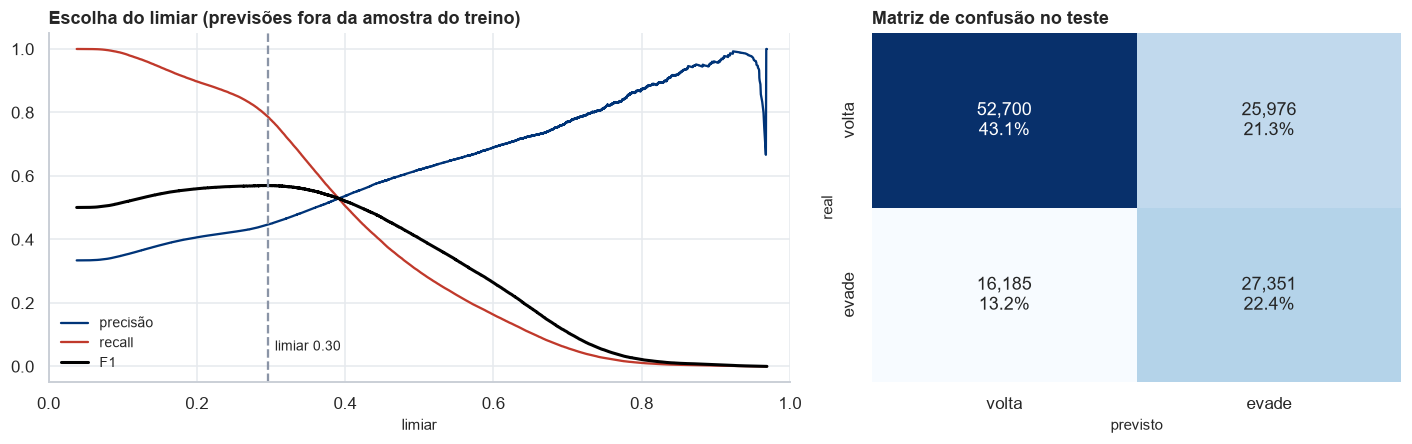

              precision    recall  f1-score   support

   volta (0)      0.765     0.670     0.714     78676
   evade (1)      0.513     0.628     0.565     43536

    accuracy                          0.655    122212
   macro avg      0.639     0.649     0.640    122212
weighted avg      0.675     0.655     0.661    122212



In [33]:
t0 = time.time()
oof = cross_val_predict(xgb_final(), X_tr, y_tr, groups=vis.loc[idx_treino, "vin"],
                        cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED),
                        method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_tr, oof)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-9, None)
LIMIAR = float(thr[np.argmax(f1s)])
FAIXAS = {"CRITICA": float(np.quantile(oof, 0.90)), "ALTA": float(np.quantile(oof, 0.70)),
          "MEDIA": float(np.quantile(oof, 0.40))}
print(f"previsões fora da amostra em {time.time() - t0:.0f}s · ROC-AUC OOF {roc_auc_score(y_tr, oof):.4f}")
print(f"limiar que maximiza o F1 no treino: {LIMIAR:.3f}")
print("cortes das faixas:", {k: round(v, 3) for k, v in FAIXAS.items()})

s_final = scores_teste[NOME_FINAL]
pred = (s_final >= LIMIAR).astype(int)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})
ax[0].plot(thr, prec[:-1], color=AZUL, label="precisão")
ax[0].plot(thr, rec[:-1], color=VERMELHO, label="recall")
ax[0].plot(thr, f1s, color="black", lw=2, label="F1")
ax[0].axvline(LIMIAR, color=CINZA, ls="--")
ax[0].text(LIMIAR + 0.01, 0.05, f"limiar {LIMIAR:.2f}", fontsize=9)
ax[0].set(title="Escolha do limiar (previsões fora da amostra do treino)", xlabel="limiar", xlim=(0, 1))
ax[0].legend(fontsize=9)
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=np.array([[f"{v:,}\n{v / cm.sum():.1%}" for v in linha] for linha in cm]), fmt="",
            cmap="Blues", cbar=False, ax=ax[1], xticklabels=["volta", "evade"], yticklabels=["volta", "evade"])
ax[1].set(title="Matriz de confusão no teste", xlabel="previsto", ylabel="real")
plt.tight_layout(); salvar(fig, "14_limiar_confusao"); plt.show()
print(classification_report(y_te, pred, target_names=["volta (0)", "evade (1)"], digits=3))

**Limiar de 0,295** (máximo F1 nas previsões fora da amostra do treino, que tiveram ROC-AUC de 0,717).

No teste, com esse limiar, o modelo **encontra 63% das evasões** (recall 0,628), e metade dos alertas é evasão de fato (precisão 0,513). O F1 vai de 0,30 no limiar 0,5 para **0,565**. A matriz mostra 27,4 mil evasões detectadas, 16,2 mil perdidas e 26 mil alarmes falsos.

Para o negócio, o alarme falso custa pouco: é um lembrete ou uma oferta para um cliente que voltaria de qualquer forma. A evasão perdida custa o cliente. Por isso faz sentido um limiar que privilegia o recall. Se a loja não tiver capacidade para tantos contatos, o caminho é trabalhar por faixa de prioridade (próxima seção), e não subir o limiar.

## 4.4 Ganho operacional

O consultor não liga para todo mundo. A pergunta prática é: **se a loja só consegue abordar uma parte da carteira, quanto da evasão essa parte cobre?**

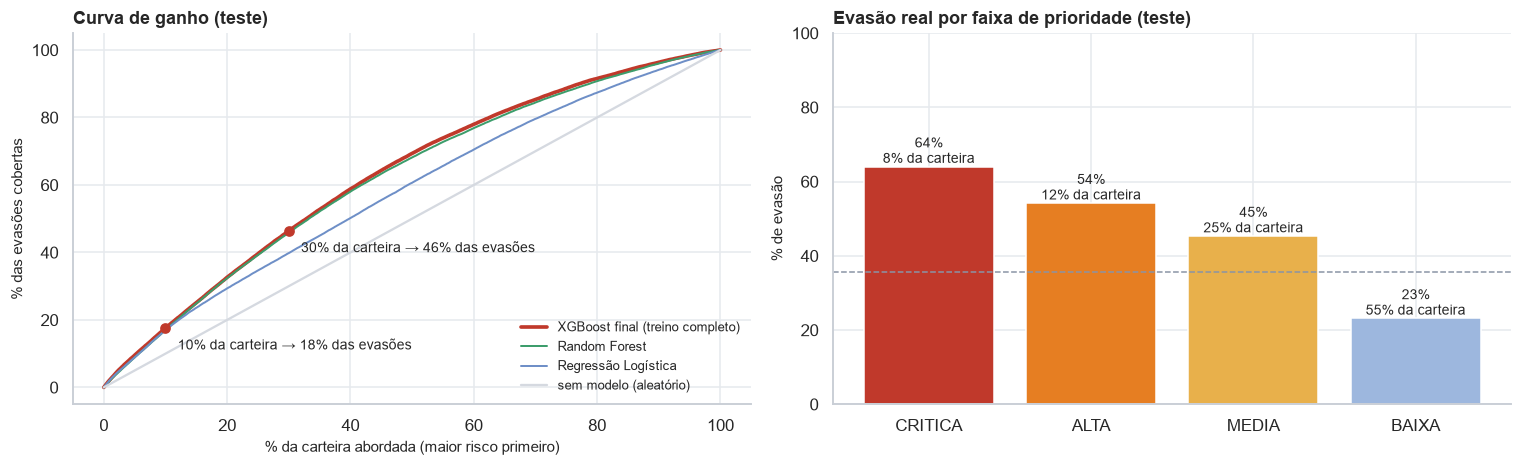

,visitas,evasao,% da carteira,% das evasões,lift
faixa,,,,,
CRITICA,9724,0.6404,0.0796,0.1430,1.7976
ALTA,14239,0.5418,0.1165,0.1772,1.5210
MEDIA,30910,0.4533,0.2529,0.3218,1.2725
BAIXA,67339,0.2314,0.5510,0.3579,0.6496


In [34]:
def curva_ganho(y_true, score):
    ordem = np.argsort(-score)
    capt = np.cumsum(np.asarray(y_true)[ordem]) / np.sum(y_true)
    return np.arange(1, len(score) + 1) / len(score), capt


fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for nome in [NOME_FINAL, "Random Forest", "Regressão Logística"]:
    x, c = curva_ganho(y_te.values, scores_teste[nome])
    ax[0].plot(x * 100, c * 100, color=CORES[nome], lw=2.4 if nome == NOME_FINAL else 1.3, label=nome)
ax[0].plot([0, 100], [0, 100], color=CINZA_CLARO, label="sem modelo (aleatório)")
x, c = curva_ganho(y_te.values, s_final)
for p in (0.1, 0.3):
    k = int(p * len(x)) - 1
    ax[0].scatter(p * 100, c[k] * 100, color=VERMELHO, zorder=3)
    ax[0].annotate(f"{p:.0%} da carteira → {c[k]:.0%} das evasões", (p * 100, c[k] * 100),
                   xytext=(8, -14), textcoords="offset points", fontsize=9)
ax[0].set(title="Curva de ganho (teste)", xlabel="% da carteira abordada (maior risco primeiro)", ylabel="% das evasões cobertas")
ax[0].legend(fontsize=8.5, loc="lower right")

teste_f = pd.DataFrame({"evasao": y_te.values, "faixa": inferencia.faixa_prioridade(s_final, FAIXAS)})
tab_faixas = (teste_f.groupby("faixa")["evasao"].agg(visitas="size", evasao="mean")
              .reindex(["CRITICA", "ALTA", "MEDIA", "BAIXA"]))
tab_faixas["% da carteira"] = tab_faixas["visitas"] / tab_faixas["visitas"].sum()
tab_faixas["% das evasões"] = tab_faixas["visitas"] * tab_faixas["evasao"] / y_te.sum()
tab_faixas["lift"] = tab_faixas["evasao"] / y_te.mean()
cores_f = [VERMELHO, "#E67E22", "#E8B04B", AZUL_CLARO]
ax[1].bar(tab_faixas.index, tab_faixas["evasao"] * 100, color=cores_f)
ax[1].axhline(y_te.mean() * 100, color=CINZA, ls="--", lw=1)
for i, (f, row) in enumerate(tab_faixas.iterrows()):
    ax[1].text(i, row["evasao"] * 100 + 1, f"{row['evasao']:.0%}\n{row['% da carteira']:.0%} da carteira", ha="center", fontsize=9)
ax[1].set(title="Evasão real por faixa de prioridade (teste)", ylabel="% de evasão", ylim=(0, 100))
plt.tight_layout(); salvar(fig, "15_ganho_faixas"); plt.show()
tab_faixas

**Ganho operacional**

- Abordando os **10%** de maior risco, o consultor cobre **18%** das evasões; com **30%** da carteira, **46%**. Sem modelo, seriam 10% e 30%.
- As faixas funcionam como prometido, com evasão real decrescente: **crítica 64%**, alta 54%, média 45%, baixa 23%. A faixa crítica tem 1,8 vez a taxa média, e a baixa 0,65 vez.
- Crítica e alta juntas são 20% da carteira e concentram 32% das evasões. É a fila que o app do consultor mostra primeiro.
- A Random Forest fica colada no XGBoost; a Regressão Logística fica visivelmente abaixo em toda a curva.

## 4.5 Calibração das probabilidades

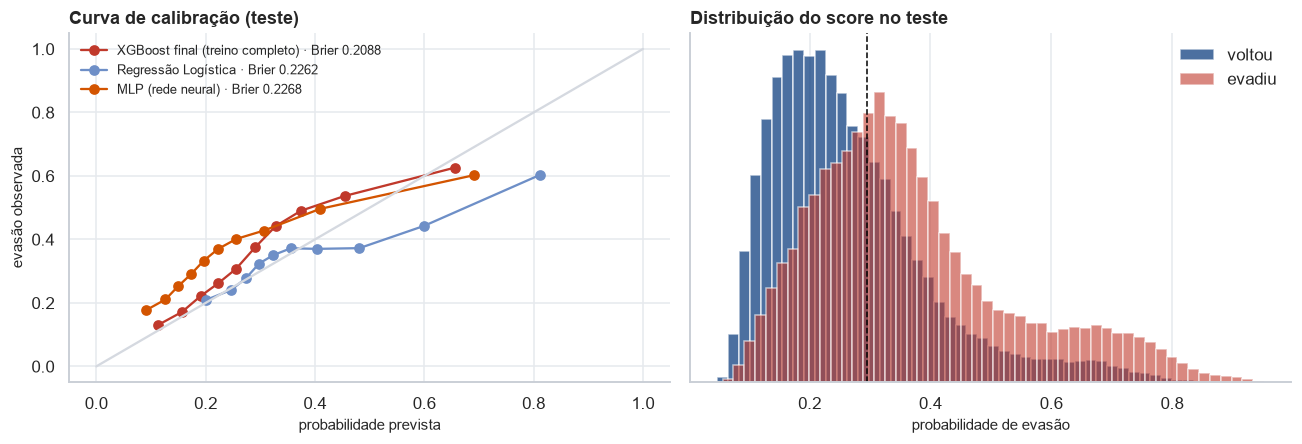

Brier de referência (prever sempre a taxa do treino): 0.2298


In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for nome in [NOME_FINAL, "Regressão Logística", "MLP (rede neural)"]:
    fp, mp = calibration_curve(y_te, scores_teste[nome], n_bins=10, strategy="quantile")
    ax[0].plot(mp, fp, "o-", color=CORES[nome], label=f"{nome} · Brier {brier_score_loss(y_te, scores_teste[nome]):.4f}")
ax[0].plot([0, 1], [0, 1], color=CINZA_CLARO)
ax[0].set(title="Curva de calibração (teste)", xlabel="probabilidade prevista", ylabel="evasão observada")
ax[0].legend(fontsize=8.5)
ax[1].hist(s_final[y_te.values == 0], bins=50, alpha=0.7, color=AZUL, label="voltou", density=True)
ax[1].hist(s_final[y_te.values == 1], bins=50, alpha=0.6, color=VERMELHO, label="evadiu", density=True)
ax[1].axvline(LIMIAR, color="black", ls="--", lw=1)
ax[1].set(title="Distribuição do score no teste", xlabel="probabilidade de evasão", yticks=[])
ax[1].legend()
plt.tight_layout(); salvar(fig, "16_calibracao"); plt.show()
print(f"Brier de referência (prever sempre a taxa do treino): {brier_score_loss(y_te, np.full(len(y_te), y_tr.mean())):.4f}")

O XGBoost é o mais bem calibrado dos três (Brier 0,209, contra 0,230 de prever sempre a média). Nos extremos a curva segue a diagonal, mas **entre 0,30 e 0,45 o modelo subestima a evasão em 8 a 11 pontos**. É o mesmo sinal de mudança temporal visto na seção 4.2: o período de teste evade mais que o de treino. A Regressão Logística é a pior no alto da escala (prevê 0,81 onde a realidade é 0,60).

Na prática, a ordenação (o que define a fila) não é afetada. Para exibir a probabilidade no app, o `ml-api` deve recalibrar periodicamente (regressão isotônica sobre as visitas de desfecho mais recente), e o monitoramento da seção 5.2 acompanha essa distância.

## 4.6 Desempenho por segmento

Um modelo bom na média pode falhar num grupo importante. Olhamos por número da revisão (a 1ª revisão é o momento mais próximo do D0 do PrevioPLS) e por modelo de veículo.

In [36]:
# lê da tabela com todas as candidatas: a seleção pode ter tirado alguma destas
seg = pd.DataFrame({"evasao": y_te.values, "score": s_final,
                    "revisao": X_todas.loc[idx_teste, "revisao"].values, "modelo": X_todas.loc[idx_teste, "modelo"].values})
seg["faixa_rev"] = pd.cut(seg["revisao"], [0, 1, 2, 3, 5, 99], labels=["1ª", "2ª", "3ª", "4ª-5ª", "6ª+"])


def resumo_seg(df, col):
    return (df.groupby(col, observed=True)
              .apply(lambda g: pd.Series({"visitas": len(g), "evasão": g["evasao"].mean(),
                                          "ROC-AUC": roc_auc_score(g["evasao"], g["score"]) if g["evasao"].nunique() > 1 else np.nan}),
                     include_groups=False))


por_rev = resumo_seg(seg, "faixa_rev")
por_mod = resumo_seg(seg, "modelo").query("visitas >= 500").sort_values("visitas", ascending=False)
display(por_rev)
por_mod

,visitas,evasão,ROC-AUC
faixa_rev,,,
1ª,"33,488.0000",0.4152,0.6653
2ª,"21,280.0000",0.3706,0.6751
3ª,"14,925.0000",0.3420,0.7018
4ª-5ª,"21,980.0000",0.3356,0.7254
6ª+,"30,539.0000",0.3034,0.7230


,visitas,evasão,ROC-AUC
modelo,,,
RANGER,"95,724.0000",0.3289,0.6907
TERRITORY,"5,609.0000",0.3186,0.6860
MAVERICK,"4,738.0000",0.4789,0.6624
BRONCO SPORT,"4,056.0000",0.4660,0.6265
KA,"3,966.0000",0.5779,0.6503
TRANSIT,"3,727.0000",0.5313,0.6930
ECOSPORT,"1,964.0000",0.5759,0.6472
F-150,"1,886.0000",0.2301,0.6283


- **Quanto mais histórico, melhor o modelo:** ROC-AUC de 0,665 na 1ª revisão contra ~0,72 a partir da 4ª. Na 1ª revisão ainda não há intervalo entre visitas nem atraso acumulado para aprender. Ela também é o ponto de maior evasão (41,5%), onde o cliente decide se fica na rede. É ali que dados de venda mais ricos (preço, financiamento, distância) fariam mais diferença.
- **Por modelo**, a ROC-AUC fica entre 0,63 (Bronco Sport, F-150) e 0,69 (Ranger, Transit). Nenhum segmento relevante fica perto do acaso, mas os modelos de menor volume têm desempenho pior, o que pede acompanhamento separado.

## 4.7 O que o modelo usa para decidir

Importância por **permutação** no teste: embaralhamos uma variável de cada vez e medimos quanto a ROC-AUC cai. A medida vale para qualquer modelo e reflete a variável original, não as colunas one-hot.

permutação em 16s


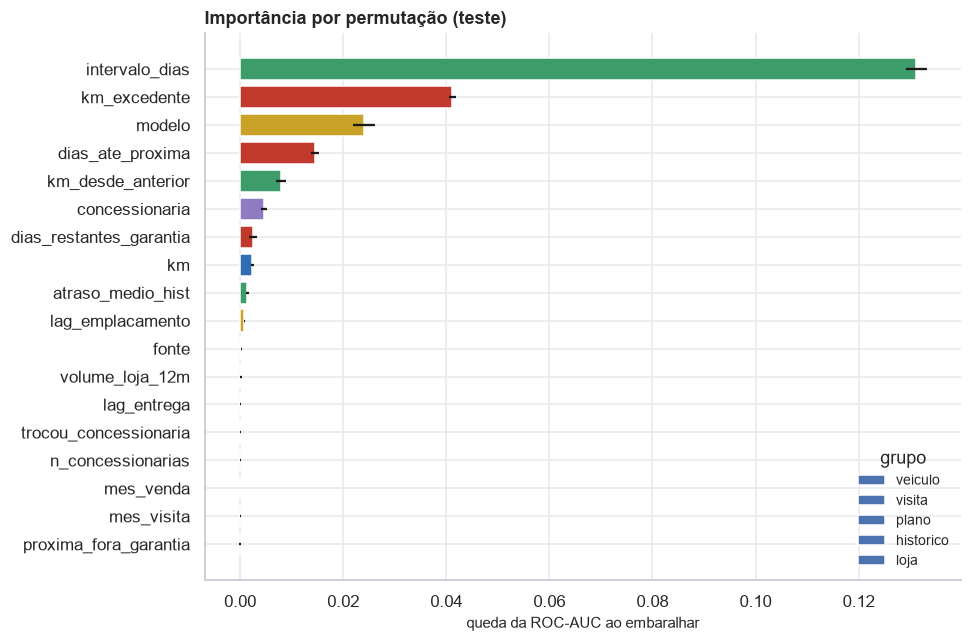

,queda ROC-AUC,desvio,grupo
intervalo_dias,0.1312,0.0021,historico
km_excedente,0.0412,0.0006,plano
modelo,0.0240,0.0021,veiculo
dias_ate_proxima,0.0145,0.0007,plano
km_desde_anterior,0.0079,0.0009,historico
concessionaria,0.0046,0.0006,loja
dias_restantes_garantia,0.0024,0.0008,plano
km,0.0024,0.0003,visita
atraso_medio_hist,0.0014,0.0003,historico
lag_emplacamento,0.0008,0.0001,veiculo


In [37]:
t0 = time.time()
amostra_pi = X_te.sample(40_000, random_state=SEED)
pi = permutation_importance(modelo_final, amostra_pi, y_te.loc[amostra_pi.index], scoring="roc_auc",
                            n_repeats=5, random_state=SEED, n_jobs=1)
imp = pd.DataFrame({"queda ROC-AUC": pi.importances_mean, "desvio": pi.importances_std},
                   index=amostra_pi.columns).sort_values("queda ROC-AUC", ascending=False)
grupo_de = {c: g for g, cols in fr.GRUPOS.items() for c in cols}
imp["grupo"] = imp.index.map(grupo_de)
print(f"permutação em {time.time() - t0:.0f}s")

cores_g = {"veiculo": "#C9A227", "visita": AZUL_MEDIO, "plano": VERMELHO, "historico": "#3C9D6B", "loja": "#8E7CC3"}
top = imp.head(18)[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top["queda ROC-AUC"], xerr=top["desvio"], color=[cores_g[g] for g in top["grupo"]])
for g, c in cores_g.items():
    ax.barh([], [], color=c, label=g)
ax.legend(title="grupo", fontsize=9)
ax.set(title="Importância por permutação (teste)", xlabel="queda da ROC-AUC ao embaralhar")
plt.tight_layout(); salvar(fig, "17_importancia"); plt.show()
imp.head(12)

- **`intervalo_dias` domina com folga** (embaralhá-lo derruba a ROC-AUC em 0,13): o tempo desde a visita anterior. Cliente que já demorou para voltar desta vez está se afastando. É o sinal mais forte da base, e ele só existe porque o modelo atua no fim de cada revisão.
- Em seguida vêm `km_excedente` (quanto a revisão atual passou do km do plano), `modelo`, `dias_ate_proxima` e `km_desde_anterior`. Os grupos **plano** e **histórico** carregam o modelo, o que confirma a ablação.
- A loja entra com peso pequeno mas real (0,005), e o volume da loja praticamente não pesa quando o resto está presente.
- Todas as variáveis importantes têm leitura de negócio direta, o que ajuda a explicar a decisão ao consultor e a cumprir o direito à explicação da LGPD (art. 20).

## 4.8 Análise dos erros

In [38]:
erro = pd.DataFrame({"real": y_te.values, "prev": pred}, index=X_te.index)
erro["tipo"] = np.select([(erro.real == 1) & (erro.prev == 1), (erro.real == 1) & (erro.prev == 0),
                          (erro.real == 0) & (erro.prev == 1)],
                         ["evasão detectada (VP)", "evasão perdida (FN)", "alarme falso (FP)"], "retorno previsto (VN)")
cols_erro = ["idade_dias", "revisao", "km_dia", "intervalo_dias", "atraso_plano_dias", "revisoes_puladas",
             "proxima_fora_garantia", "agendado"]
perfil_erro = X_todas.loc[X_te.index, cols_erro].join(erro["tipo"]).groupby("tipo").median().T
perfil_erro.loc["visitas"] = erro["tipo"].value_counts()
fn = erro["tipo"] == "evasão perdida (FN)"
retorno_fn = prox_visita.loc[erro.index[fn]].notna().mean()
print(f"das evasões perdidas, {retorno_fn:.0%} voltaram depois do prazo (evasão tardia); o resto não voltou até a extração")
perfil_erro

das evasões perdidas, 54% voltaram depois do prazo (evasão tardia); o resto não voltou até a extração


tipo,alarme falso (FP),evasão detectada (VP),evasão perdida (FN),retorno previsto (VN)
idade_dias,493.0000,518.0000,387.0000,489.0000
revisao,3.0000,3.0000,2.0000,3.0000
km_dia,70.8518,64.0066,89.3941,92.8057
intervalo_dias,216.0000,253.0000,140.0000,124.0000
atraso_plano_dias,-375.5000,-278.0000,-479.0000,-710.0000
revisoes_puladas,0.0000,0.0000,0.0000,0.0000
proxima_fora_garantia,0.0000,0.0000,0.0000,0.0000
agendado,1.0000,1.0000,1.0000,1.0000
visitas,"25,976.0000","27,351.0000","16,185.0000","52,700.0000"


- **Evasões perdidas (FN)** parecem clientes exemplares: voltaram rápido desta vez (intervalo mediano de 140 dias), rodam muito (89 km/dia) e são mais novos. O modelo não tinha como antecipá-las. **54% delas voltaram, só que depois do prazo**, então parte do "erro" é evasão tardia, a forma mais branda.
- **Alarmes falsos (FP)** têm perfil de risco (intervalo mediano de 216 dias, contra 124 de quem o modelo acertou que volta) e mesmo assim voltaram. Para esse grupo, a abordagem do consultor custa pouco e pode ter ajudado a trazê-los.

---
# 5. Conclusão

## 5.1 Modelo selecionado

In [39]:
m = comp_teste.loc[NOME_FINAL]
rl = comp_teste.loc["Regressão Logística"]
x, c = curva_ganho(y_te.values, s_final)
cobre_30 = c[int(0.3 * len(x)) - 1]
print(f"modelo: XGBoost, {sum(1 for _ in PARAMS_FINAIS)} hiperparâmetros ajustados, treinado em {len(X_tr):,} visitas")
print(f"teste temporal ({len(X_te):,} visitas, {y_te.mean():.1%} de evasão):")
print(f"  ROC-AUC {m['ROC-AUC']:.3f} · PR-AUC {m['PR-AUC']:.3f} · Brier {m['Brier']:.4f}")
print(f"  no limiar {LIMIAR:.2f}: F1 {f1_score(y_te, pred):.3f} · precisão {precision_score(y_te, pred):.3f} · recall {recall_score(y_te, pred):.3f}")
print(f"  abordando 30% da carteira pelo risco, o consultor cobre {cobre_30:.0%} das evasões (sem modelo: 30%)")
print(f"  vs regressão logística: +{m['ROC-AUC'] - rl['ROC-AUC']:.3f} de ROC-AUC e +{m['PR-AUC'] - rl['PR-AUC']:.3f} de PR-AUC")

modelo: XGBoost, 8 hiperparâmetros ajustados, treinado em 250,383 visitas
teste temporal (122,212 visitas, 35.6% de evasão):
  ROC-AUC 0.698 · PR-AUC 0.547 · Brier 0.2088
  no limiar 0.30: F1 0.565 · precisão 0.513 · recall 0.628
  abordando 30% da carteira pelo risco, o consultor cobre 46% das evasões (sem modelo: 30%)
  vs regressão logística: +0.074 de ROC-AUC e +0.060 de PR-AUC


**XGBoost é o modelo selecionado**, pelas razões abaixo:

1. **Melhor desempenho** na validação cruzada (0,712) e no teste temporal (0,698 de ROC-AUC e 0,547 de PR-AUC), à frente da Random Forest nas duas etapas.
2. **Menor sobreajuste** entre os modelos competitivos (0,037 contra 0,156 da Random Forest).
3. **Mais robusto à mudança no tempo**: perdeu 0,025 do CV para o teste (mesma amostra de treino), contra 0,076 da Regressão Logística e 0,107 do KNN.
4. **Melhor calibrado** (Brier 0,209) e **leve para produção**: artefato de 0,4 MB, pontuação em milissegundos, sem GPU.
5. **Interpretável o suficiente**: as variáveis que mais pesam têm leitura direta de negócio.

**Principais resultados:** com o limiar escolhido no treino, o modelo encontra 63% das evasões do período de teste; a faixa crítica evade 64%, contra 23% da faixa baixa; e abordar 30% da carteira cobre 46% das evasões, 1,5 vez o que se cobriria sem o modelo.

## 5.2 Como o modelo entra no PrevioPLS

O monorepo do PrevioPLS já tem um serviço de inferência (`ml-api`, FastAPI + scikit-learn) chamado pelo core Spring Boot. O modelo desta sprint entra no lugar do classificador D0 anterior, e o fluxo fica assim:

1. **A OS de revisão fecha** no sistema da concessionária. O core recebe o evento e monta o histórico do VIN (visitas anteriores + dados do veículo) e o volume da loja nos últimos 12 meses.
2. O core chama `POST /predict` no `ml-api`, que executa `src/inferencia.py`: reconstrói as features com a **mesma função** do treino (`features_revisao.py`), aplica o pipeline exportado (`models/modelo_evasao.joblib`) e devolve probabilidade, faixa de prioridade, perfil sugerido e data estimada da próxima revisão.
3. Se a probabilidade passa do limiar, o core **cria um lead** com prioridade pela faixa e o script comercial do perfil (Fiel, Econômico, Esquecido, Abandono, já existentes no PrevioPLS).
4. O **app do consultor** recebe push nos leads críticos e mostra a visão 360 do veículo; o resultado do contato volta pelo PATCH do lead e alimenta o próximo retreino.

**Forma de deploy proposta**

| Peça | Como |
|---|---|
| artefato | pipeline completo em `joblib` (pré-processamento + XGBoost) + `metadata.json` com features, limiar, faixas e métricas |
| serviço | container do `ml-api` (FastAPI) no Render, carregando o artefato no boot; a checagem anti-vazamento que o serviço já faz no startup continua valendo |
| modo online | uma chamada por OS fechada; latência de milissegundos, sem GPU |
| modo lote | job noturno repontua toda a carteira aberta, porque o risco muda com o tempo mesmo sem visita nova |
| monitoramento | PSI das features de entrada por semana; ROC-AUC mensal sobre as visitas cujo prazo venceu; alerta se cair mais de 0,03 |
| retreino | trimestral, ou quando o monitoramento acusar deriva; o novo modelo só entra se superar o atual no teste temporal |
| LGPD | o modelo não usa dado pessoal (chassi em hash); cada score fica na auditoria com a versão do modelo; o consultor pode discordar do lead, e isso garante a revisão humana do art. 20 |

## 5.3 Exportação e a fila de hoje

O modelo de produção é treinado com **todas** as visitas de desfecho conhecido (treino + teste). Depois ele pontua a carteira que ainda está com a janela aberta na data da extração: é a lista que o consultor receberia hoje.

In [40]:
t0 = time.time()
idx_prod = vis.index[observavel]
modelo_producao = xgb_final().fit(X_todas.loc[idx_prod, FEATURES], y.loc[idx_prod])
joblib.dump(modelo_producao, DIR_MODELO / "modelo_evasao.joblib", compress=3)


def py(v):
    return v.item() if hasattr(v, "item") else v


meta = {
    "versao": "sprint3-2026.09",
    "algoritmo": "XGBoost (pipeline scikit-learn)",
    "treinado_com": {"visitas": int(len(idx_prod)), "ate": f"{DATA_EXTRACAO:%Y-%m-%d}"},
    "hiperparametros": {k.replace("clf__", ""): py(v) for k, v in PARAMS_FINAIS.items()},
    "features": FEATURES,
    "alvo": {"definicao": "sem visita na rede até min(365 dias, 10 mil km) + tolerância", "tolerancia_dias": TOLERANCIA},
    "limiar": LIMIAR,
    "faixas": FAIXAS,
    "metricas_teste": {k: round(float(v), 4) for k, v in comp_teste.loc[NOME_FINAL].drop("treinado em").items()},
    "modelos_conhecidos": sorted(X_todas["modelo"].unique().tolist()),
    "versoes": {"python": sys.version.split()[0], "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
                "xgboost": xgboost.__version__},
}
(DIR_MODELO / "metadata.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
tamanho = (DIR_MODELO / "modelo_evasao.joblib").stat().st_size / 1e6
print(f"modelo de produção treinado em {len(idx_prod):,} visitas ({time.time() - t0:.0f}s) · artefato de {tamanho:.1f} MB")

ultimas = vis.groupby("vin").tail(1).index
fila = ultimas[~observavel.loc[ultimas].values]
F_fila = X_todas.loc[fila]
score_fila = modelo_producao.predict_proba(F_fila[FEATURES])[:, 1]
fila_df = pd.DataFrame({
    "faixa": inferencia.faixa_prioridade(score_fila, FAIXAS),
    "perfil": inferencia.perfil_sugerido(F_fila, score_fila, LIMIAR),
    "lead": score_fila >= LIMIAR,
}, index=fila)
print(f"carteira aberta em {DATA_EXTRACAO:%d/%m/%Y}: {len(fila):,} veículos · {fila_df['lead'].sum():,} viram lead")

# a fila não tem a mesma cara do teste: janela aberta dura mais pra quem roda pouco
perfil_fila = pd.DataFrame({
    "teste (desfecho conhecido)": [s_final.mean(), y_te.mean(), np.mean(s_final >= FAIXAS["CRITICA"]),
                                   X_todas.loc[idx_teste, "km_dia"].median(), X_todas.loc[idx_teste, "intervalo_dias"].median(),
                                   X_todas.loc[idx_teste, "proxima_fora_garantia"].mean()],
    "fila aberta hoje": [score_fila.mean(), np.nan, np.mean(score_fila >= FAIXAS["CRITICA"]),
                         F_fila["km_dia"].median(), F_fila["intervalo_dias"].median(), F_fila["proxima_fora_garantia"].mean()],
}, index=["score médio", "evasão real", "% na faixa crítica", "km/dia (mediana)",
          "dias desde a visita anterior (mediana)", "% com a próxima revisão fora da garantia"])
display(perfil_fila.round(3))
pd.crosstab(fila_df["faixa"], fila_df["perfil"], margins=True, margins_name="total").reindex(
    ["CRITICA", "ALTA", "MEDIA", "BAIXA", "total"])

modelo de produção treinado em 438,168 visitas (16s) · artefato de 0.4 MB


carteira aberta em 04/05/2026: 81,479 veículos · 58,829 viram lead


,teste (desfecho conhecido),fila aberta hoje
score médio,0.3040,0.4350
evasão real,0.3560,NaN
% na faixa crítica,0.0800,0.2710
km/dia (mediana),79.3160,54.3840
dias desde a visita anterior (mediana),168.0000,258.0000
% com a próxima revisão fora da garantia,0.2160,0.2660


perfil,ABANDONO,ECONOMICO,ESQUECIDO,FIEL,total
faixa,,,,,
CRITICA,2181,2757,17180,0,22118
ALTA,4306,1925,15904,0,22135
MEDIA,6498,990,7088,640,15216
BAIXA,0,0,0,22010,22010
total,12985,5672,40172,22650,81479


**A fila de 04/05/2026:** 81,5 mil veículos com janela aberta, 22 mil na faixa crítica (27%, contra 8% no teste).

A diferença vem da **composição da carteira aberta**, e não de um defeito do modelo. A janela fica aberta mais tempo para quem roda pouco (12 meses até a próxima revisão, contra 3 ou 4 meses de quem roda muito), então a carteira aberta concentra carros de uso baixo (mediana de 54 km/dia, contra 79 no teste), com mais tempo desde a última visita (258 contra 168 dias) e mais próximos do fim da garantia (27% contra 22%). São exatamente os sinais que a seção 4.7 mostrou pesarem a favor da evasão. E o modelo não está exagerando o risco: no teste, o score médio (0,304) ficou **abaixo** da evasão real (0,356), como a calibração já indicava.

Com essa fila, o limiar de F1 geraria 58,8 mil leads, mais do que a rede consegue trabalhar. A recomendação operacional é **distribuir por faixa conforme a capacidade**: primeiro os 22 mil críticos (~51 por concessionária), depois os altos. O perfil sugerido define o script: "Esquecido" (chegou atrasado nesta revisão) recebe lembrete e agendamento facilitado; "Abandono" recebe a oferta mais agressiva; "Econômico" (já fez revisão fora da rede) recebe o comparativo de custo.

## 5.4 Uma chamada de ponta a ponta

Pegamos um veículo real da fila crítica, montamos a requisição que o core mandaria e chamamos `src/inferencia.py`. O score precisa bater com o calculado aqui no notebook; se não bater, treino e produção estariam fazendo contas diferentes.

In [41]:
critico = fila_df.index[(fila_df["faixa"] == "CRITICA") & (X_todas.loc[fila_df.index, "n_visitas_anteriores"] >= 2)][0]
hist = vis[vis["vin"] == vis.loc[critico, "vin"]].sort_values("data")
iso = lambda d: None if pd.isna(d) else f"{d:%Y-%m-%d}"
requisicao = {
    "veiculo": {c: (iso(hist[c].iloc[0]) if c.startswith("data") else py(hist[c].iloc[0]))
                for c in ["modelo", "ano_modelo", "data_nf", "data_venda", "data_entrega", "data_emplacamento", "data_garantia"]},
    "visitas": [{"data": iso(r.data), "abertura": iso(r.abertura), "fechamento": iso(r.fechamento),
                 "revisao": int(r.revisao), "km": None if pd.isna(r.km) else float(r.km),
                 "concessionaria": r.concessionaria, "fonte": r.fonte, "agendado": bool(r.agendado),
                 "codigo_servico": r.codigo_servico} for r in hist.itertuples()],
    "volume_loja_12m": float(X_todas.loc[critico, "volume_loja_12m"]),
}
(RAIZ / "src" / "exemplo_requisicao.json").write_text(json.dumps(requisicao, ensure_ascii=False, indent=2), encoding="utf-8")

inferencia.carregar.cache_clear()
resposta = inferencia.classificar(requisicao)
score_notebook = float(modelo_producao.predict_proba(X_todas.loc[[critico], FEATURES])[0, 1])
print(json.dumps(resposta, ensure_ascii=False, indent=2))
assert abs(resposta["probabilidade_evasao"] - round(score_notebook, 4)) < 1e-4, "treino e inferência divergem"
print(f"score calculado no notebook: {score_notebook:.4f} · idêntico ao da inferência")

{
  "probabilidade_evasao": 0.6606,
  "prioridade": "CRITICA",
  "gera_lead": true,
  "perfil_sugerido": "ESQUECIDO",
  "proxima_revisao_estimada": "2026-05-04",
  "versao_modelo": "sprint3-2026.09"
}
score calculado no notebook: 0.6606 · idêntico ao da inferência


## 5.5 Melhorias e trabalhos futuros

| Limitação | Próximo passo |
|---|---|
| A base só tem quem já passou pela rede; o comprador que nunca aparece fica de fora | cruzar com a base de vendas da Ford (o denominador do VIN Share) para treinar o classificador D0 que o PrevioPLS prometia desde a Sprint 1 |
| Não há valor da OS, preço nem desconto | com o valor do serviço, o perfil **Econômico** deixa de ser regra e vira alvo aprendido; também dá para estimar receita em risco por lead |
| Não sabemos onde o cliente mora | a distância entre cliente e loja é forte candidata a explicar parte da evasão; o CEP do cadastro permitiria medi-la |
| O alvo é binário e perde o "quando" | análise de sobrevivência (Cox, *random survival forest*) para estimar o tempo até o retorno e tratar a censura em vez de descartá-la |
| O modelo diz quem vai sair, não quem pode ser convencido | *uplift modeling* com o resultado das abordagens registradas no app, para priorizar quem muda de ideia com o contato |
| Retreino e monitoramento ainda são manuais | pipeline de MLOps (MLflow ou equivalente) com registro de versões, PSI das features e reavaliação mensal automática |
| Dados conectados não foram usados | telemetria (FordPass / veículo conectado) daria km em tempo real, e com isso o vencimento exato da revisão em vez da estimativa por média |